In [1]:
import seisbench.data as sbd
import seisbench.models as sbm
import matplotlib.pyplot as plt
import numpy as np

path1 = 'D:\\seisbench_data\\vcseis\\ak_lp'
path2 = 'D:\\seisbench_data\\vcseis\\ak_vt'
path3 = 'D:\\seisbench_data\\vcseis\\ak_ns'

data1 = sbd.WaveformDataset(path1)
data2 = sbd.WaveformDataset(path2)
data3 = sbd.WaveformDataset(path3)

idx1 = 1000
idx2 = 1000
idx3 = 1000


2026-06-20 06:10:18,580 | seisbench | WARNING | Output component order not specified, defaulting to 'ZNE'.
2026-06-20 06:10:18,817 | seisbench | WARNING | Output component order not specified, defaulting to 'ZNE'.
2026-06-20 06:10:18,843 | seisbench | WARNING | Output component order not specified, defaulting to 'ZNE'.


### Waveform data visualize

2026-06-20 06:10:24,211 | seisbench | WARNING | Output component order not specified, defaulting to 'ZNE'.


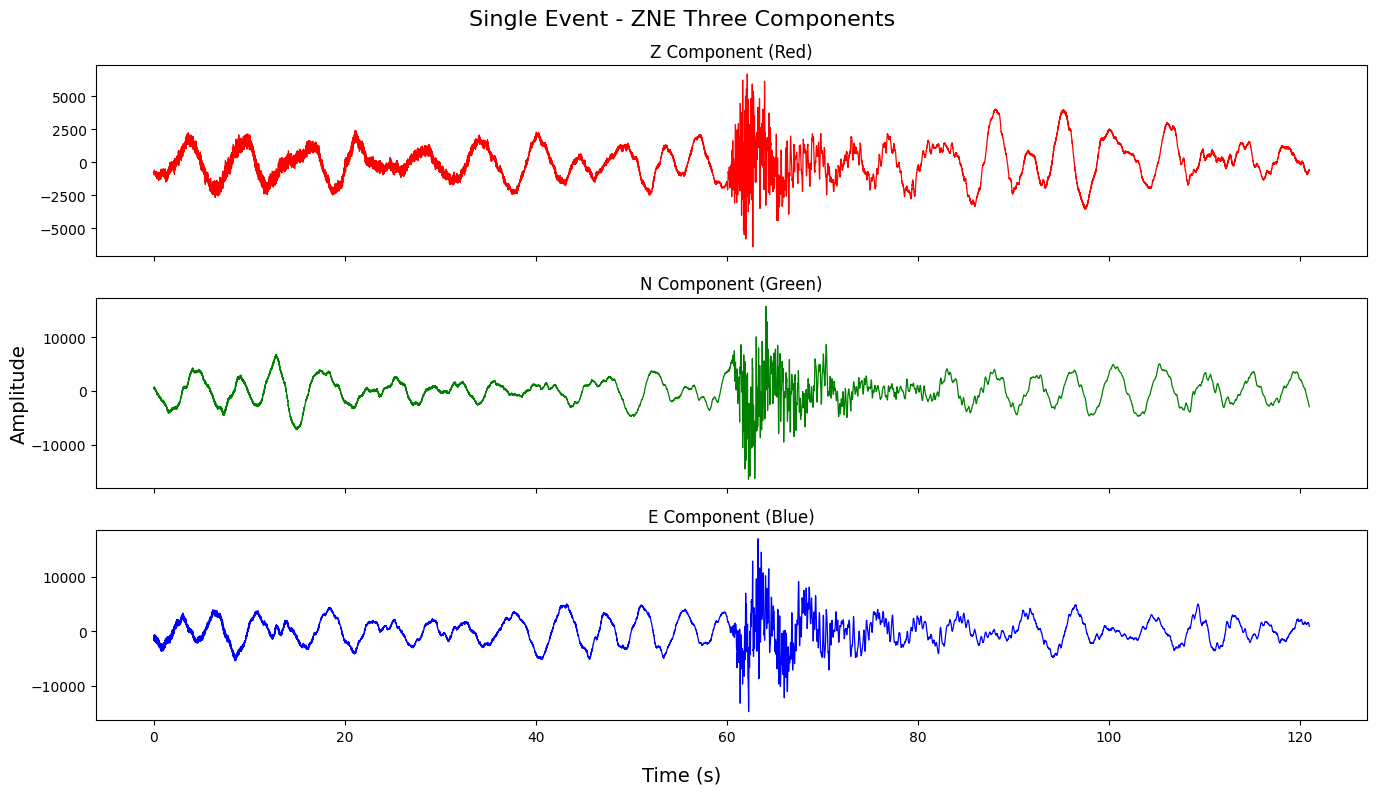

In [2]:
# --------------------------
# 1. Only load one event（ path1: LP， path2: VT , path3: noise）
# --------------------------
path1 = 'D:\\seisbench_data\\vcseis\\hw_lp'  
data1 = sbd.WaveformDataset(path1)
idx1 = 1000

# --------------------------
# 2. read Z / N / E waveform data & sampling rate
# --------------------------
wf1 = data1.get_waveforms(idx1)  # shape = (3, npts) → Z, N, E
sr1 = data1.metadata.iloc[idx1]['trace_sampling_rate_hz']
t1 = np.arange(wf1.shape[1]) / sr1

# 3 channels
z = wf1[0]
n = wf1[1]
e = wf1[2]

# --------------------------
# 3. 3 subplot，Z=red，N=green，E=blue
# --------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Single Event - ZNE Three Components", fontsize=16)

axes[0].plot(t1, z, color='red', linewidth=0.9)
axes[0].set_title("Z Component (Red)", fontsize=12)

axes[1].plot(t1, n, color='green', linewidth=0.9)
axes[1].set_title("N Component (Green)", fontsize=12)

axes[2].plot(t1, e, color='blue', linewidth=0.9)
axes[2].set_title("E Component (Blue)", fontsize=12)

fig.supxlabel("Time (s)", fontsize=14)
fig.supylabel("Amplitude", fontsize=14)

plt.subplots_adjust(hspace=0.4)
plt.tight_layout()

# save as PDF
'''
plt.savefig(
    r"D:\\seisbench_data\\fig\\single_event_zne_rgb.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300
)
'''

plt.show()

### Z componet of each type of event

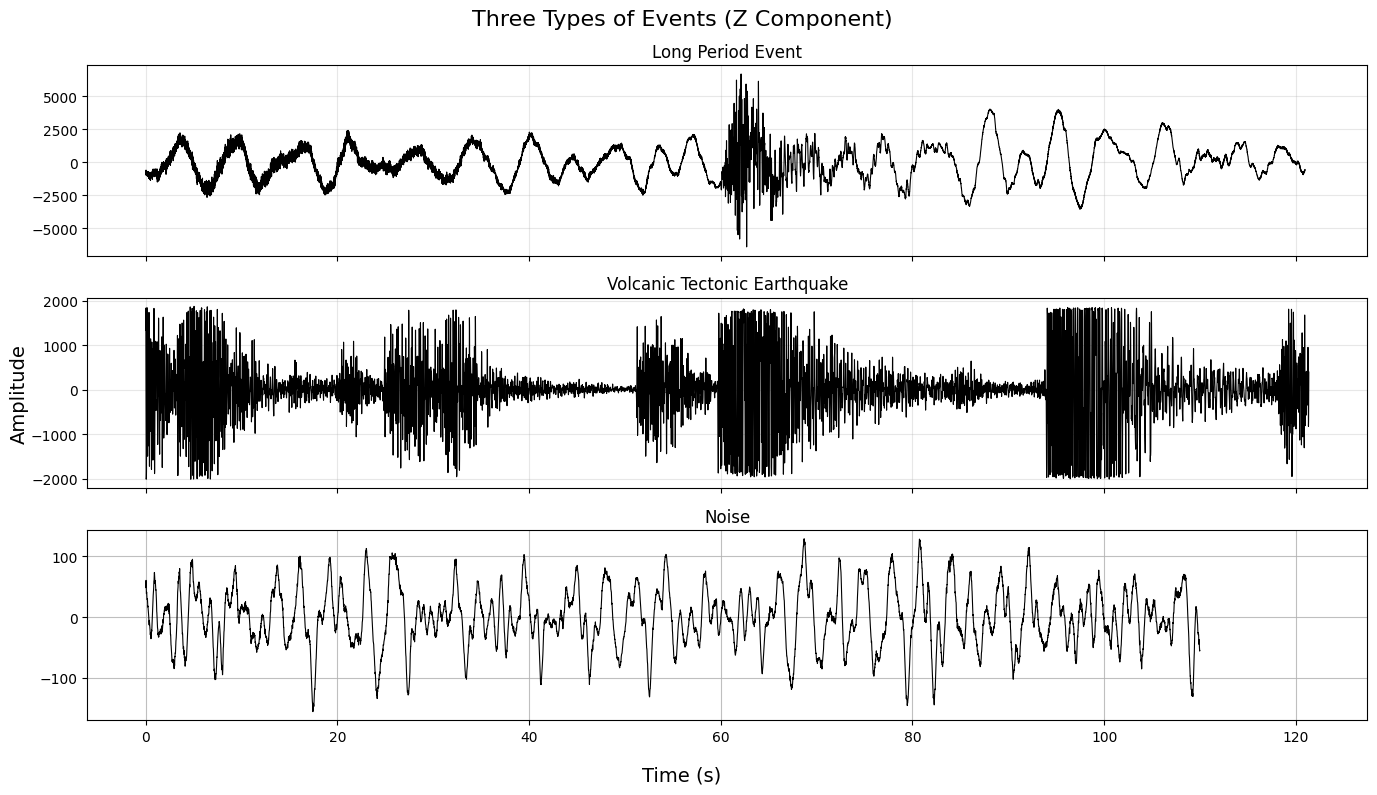

In [3]:

wf1 = data1.get_waveforms(idx1)
wf2 = data2.get_waveforms(idx2)
wf3 = data3.get_waveforms(idx3)

sr1 = data1.metadata.iloc[idx1]['trace_sampling_rate_hz']
sr2 = data2.metadata.iloc[idx2]['trace_sampling_rate_hz']
sr3 = data3.metadata.iloc[idx3]['trace_sampling_rate_hz']

t1 = np.arange(wf1.shape[1]) / sr1
t2 = np.arange(wf2.shape[1]) / sr2
t3 = np.arange(wf3.shape[1]) / sr3


fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Three Types of Events (Z Component)", fontsize=16)

axes[0].plot(t1, wf1[0], 'k', linewidth=0.8)
axes[0].set_title("Long Period Event", fontsize=12)
axes[0].grid(alpha=0.3)

axes[1].plot(t2, wf2[0], 'k', linewidth=0.8)
axes[1].set_title("Volcanic Tectonic Earthquake", fontsize=12)
axes[1].grid(alpha=0.3)

axes[2].plot(t3, wf3[0], 'k', linewidth=0.8)
axes[2].set_title("Noise", fontsize=12)
axes[2].grid(alpha=0.8)

fig.supxlabel("Time (s)", fontsize=14)       
fig.supylabel("Amplitude", fontsize=14)     
plt.subplots_adjust(hspace=0.4)

plt.tight_layout()

'''
plt.savefig(
    r"D:\\seisbench_data\\fig\\three_events_Z.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300
)
'''
plt.show()

### PSD visualize

2026-06-20 06:17:01,210 | seisbench | WARNING | Output component order not specified, defaulting to 'ZNE'.
2026-06-20 06:17:01,443 | seisbench | WARNING | Output component order not specified, defaulting to 'ZNE'.
2026-06-20 06:17:01,474 | seisbench | WARNING | Output component order not specified, defaulting to 'ZNE'.


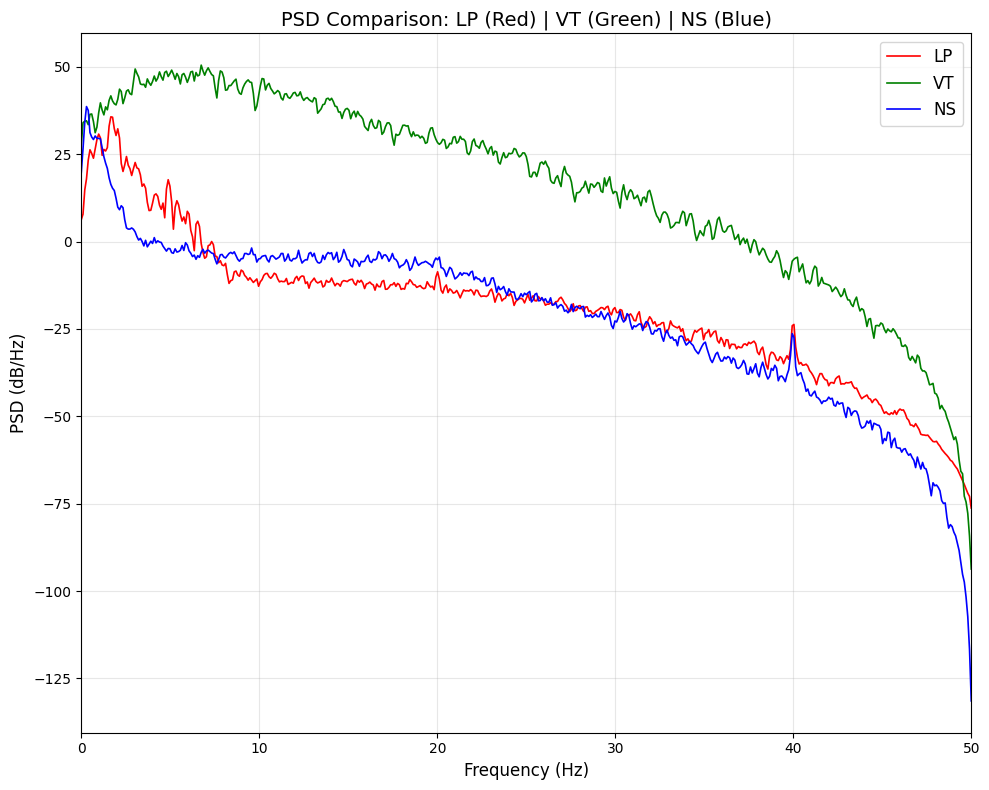

In [4]:
from scipy.signal import welch

paths = [
    r'D:\\seisbench_data\\vcseis\\ak_lp',
    r'D:\seisbench_data\\vcseis\\ak_vt',
    r'D:\seisbench_data\\vcseis\\ak_ns'
]

labels = ["LP", "VT", "NS"]
colors = ["red", "green", "blue"] 

idx = 1000

fig, ax = plt.subplots(figsize=(10, 8))

for i, p in enumerate(paths):
    data = sbd.WaveformDataset(p)
    wf = data.get_waveforms(idx)
    z = wf[0]
    sr = data.metadata.iloc[idx]["trace_sampling_rate_hz"]
    
    freq, psd = welch(z, fs=sr, nperseg=1024, noverlap=512)
    psd_db = 10 * np.log10(psd)
    
    ax.plot(freq, psd_db, label=labels[i], color=colors[i], linewidth=1.2)

ax.set_xlabel("Frequency (Hz)", fontsize=12)
ax.set_ylabel("PSD (dB/Hz)", fontsize=12)
ax.set_title("PSD Comparison: LP (Red) | VT (Green) | NS (Blue)", fontsize=14)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
ax.set_xlim(0, 50) 

plt.tight_layout()

'''
# 保存矢量PDF
plt.savefig(r"D:\\seisbench_data\\fig\\psd_rgb.pdf", format="pdf", bbox_inches="tight")
'''
plt.show()

### Time-frequency

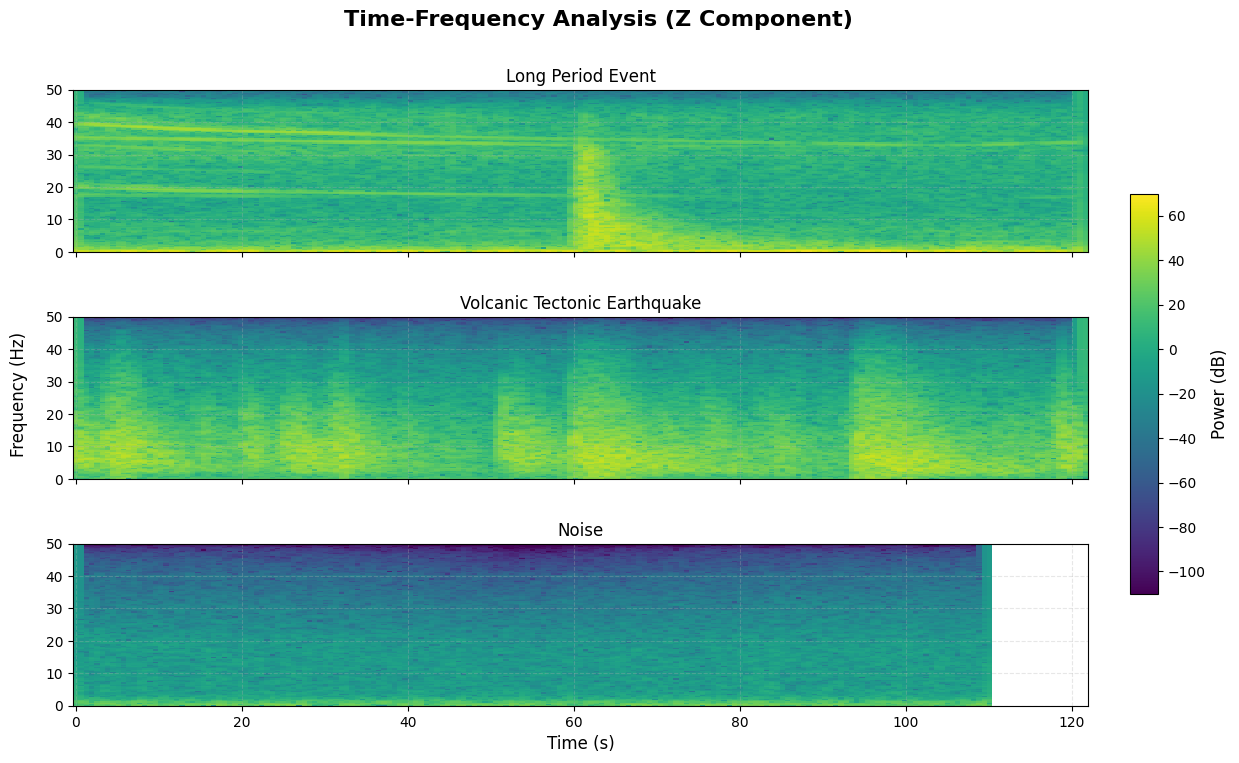

In [5]:
from scipy.signal import stft


def get_z_sr(ds, idx):
    wf = ds.get_waveforms(idx)
    sig = wf[0]
    sr = ds.metadata.iloc[idx]["trace_sampling_rate_hz"]
    return sig, sr

z1, sr1 = get_z_sr(data1, idx)
z2, sr2 = get_z_sr(data2, idx)
z3, sr3 = get_z_sr(data3, idx)

def stft_tf(signal, fs):
    f, t, Zxx = stft(signal, fs=fs, nperseg=256, noverlap=192)
    spec_db = 20 * np.log10(np.abs(Zxx) + 1e-10)
    return t, f, spec_db

t1, f1, spec1 = stft_tf(z1, sr1)
t2, f2, spec2 = stft_tf(z2, sr2)
t3, f3, spec3 = stft_tf(z3, sr3)

all_spec = np.concatenate([spec1.flatten(), spec2.flatten(), spec3.flatten()])
vmin = -110
vmax = all_spec.max()

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Time-Frequency Analysis (Z Component)", fontsize=16, fontweight="bold")

title_list = ["Long Period Event", "Volcanic Tectonic Earthquake", "Noise"]
cmap = "viridis"

ims = []
for i, (t, f, spec) in enumerate([(t1, f1, spec1), (t2, f2, spec2), (t3, f3, spec3)]):
    ax = axes[i]
    im = ax.pcolormesh(t, f, spec, cmap=cmap, vmin=vmin, vmax=vmax, shading='auto')
    ims.append(im)
    
    ax.set_title(title_list[i], fontsize=12)
    ax.set_ylim(0, 50)
    ax.grid(alpha=0.3, linestyle='--')
    
    if i == 2:
        ax.set_xlabel("Time (s)", fontsize=12)

fig.supylabel("Frequency (Hz)", fontsize=12, x=0.08)  

plt.subplots_adjust(hspace=0.4, right=0.85)

cbar_ax = fig.add_axes([0.88, 0.25, 0.02, 0.5])
cbar = fig.colorbar(ims[0], cax=cbar_ax)
cbar.set_label("Power (dB)", fontsize=12)

# plt.savefig(r"D:\seisbench_data\fig\tf_vertical.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Event distribution

Temp dir: D:\pygmt_temp
LP: 4841 events have been loaded
VT: 4841 events have been loaded
✓ submap have been added
✅ map have been saved: D:/NorthernCalifornia_FINAL_MAP.pdf


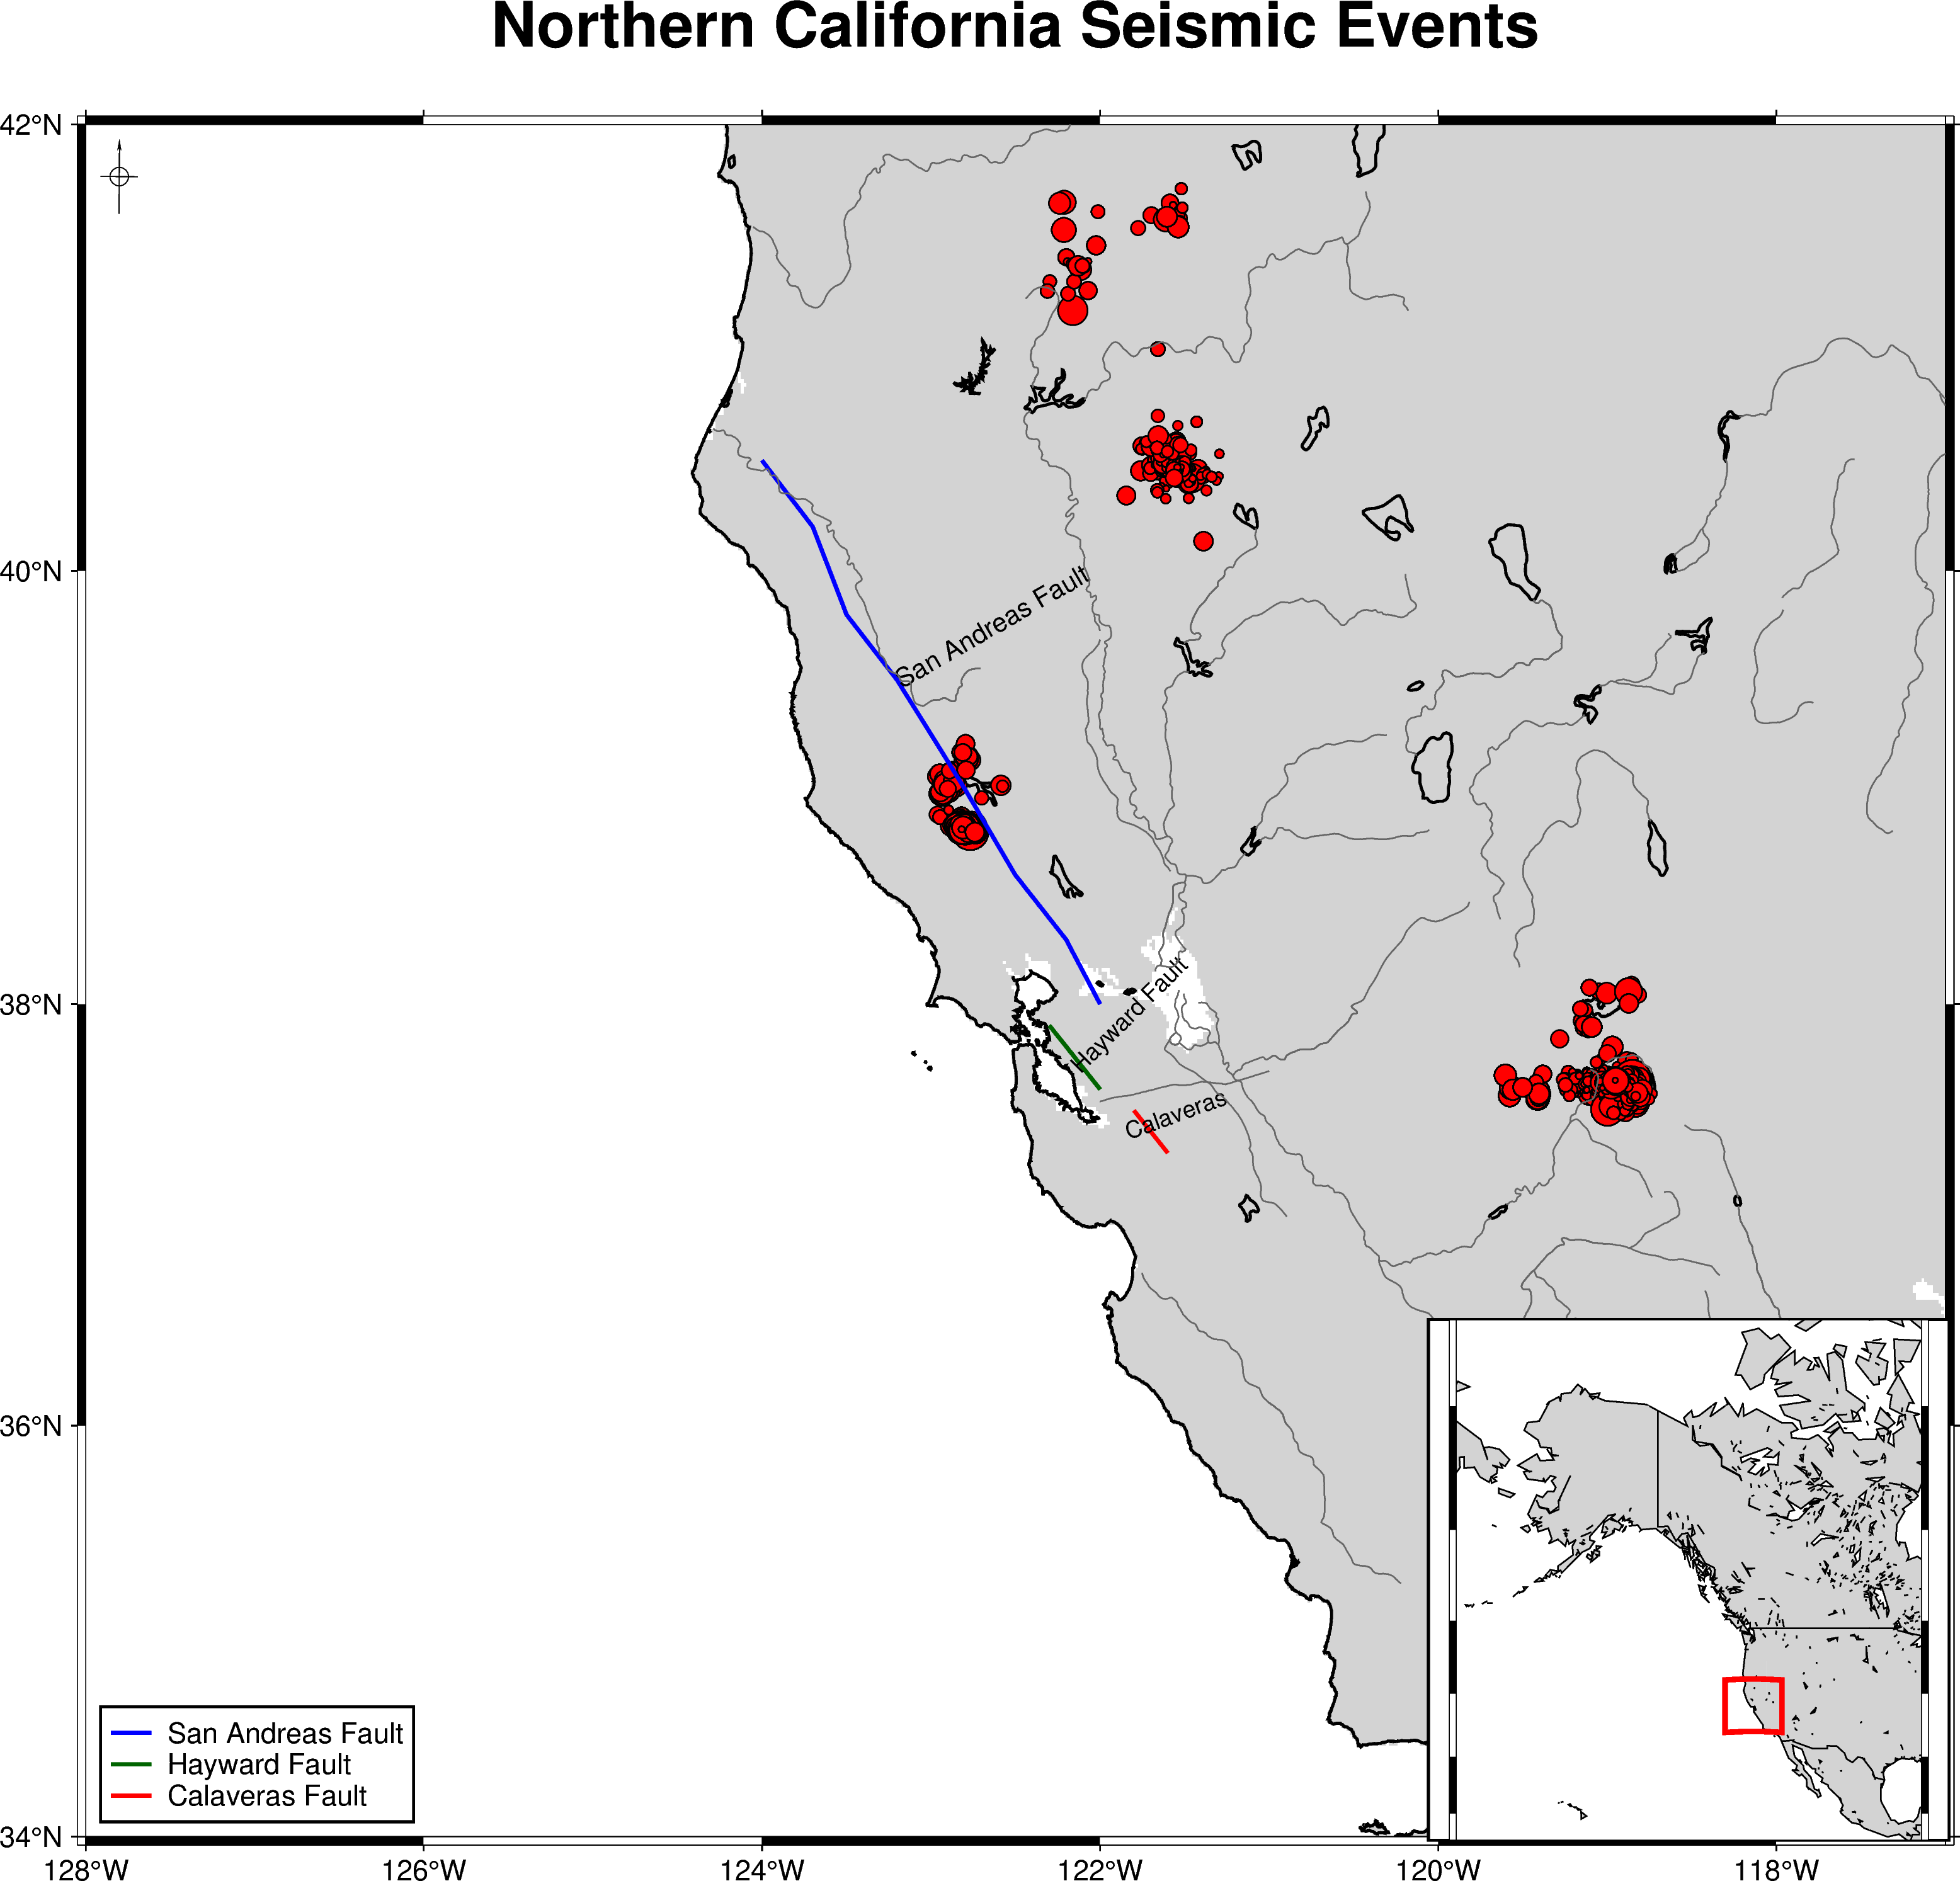

In [6]:
import os
import sys
import pygmt
import pandas as pd
import numpy as np
from pathlib import Path


TEMP_DIR = r"D:\pygmt_temp"
os.makedirs(TEMP_DIR, exist_ok=True)
os.environ["TMPDIR"] = TEMP_DIR
os.environ["GMT_TMPDIR"] = TEMP_DIR
os.chdir(TEMP_DIR)
print(f"Temp dir: {TEMP_DIR}")

DEBUG = True

def normalize_longitude(lon):
    if lon > 180:
        return lon - 360
    elif lon < -180:
        return lon + 360
    return lon

def load_events(file_path):
    if not file_path.exists():
        print(f"⚠️ no such file: {file_path}")
        return pd.DataFrame()
    df = pd.read_csv(file_path)
    rename_dict = {}
    if 'source_longitude_deg' in df.columns:
        rename_dict['source_longitude_deg'] = 'longitude'
    if 'source_latitude_deg' in df.columns:
        rename_dict['source_latitude_deg'] = 'latitude'
    if rename_dict:
        df = df.rename(columns=rename_dict)
    if 'longitude' in df.columns:
        df['longitude'] = df['longitude'].apply(normalize_longitude)
    return df

base_dir = Path("D:/seisbench_data/vcseis")
csv_files = {
    "LP": base_dir / "nc_lp" / "metadata_ncedc_lp.csv",
    "VT": base_dir / "nc_vt" / "metadata_ncedc_vt.csv",
}

dfs = []
for name, f in csv_files.items():
    df = load_events(f)
    if not df.empty:
        dfs.append(df)
        if DEBUG: print(f"{name}: {len(df)} events have been loaded")
    else:
        if DEBUG: print(f" {name} have been passed")

if not dfs:
    np.random.seed(42)
    n_sim = 200
    sim_lon = np.random.uniform(-124, -120, n_sim)
    sim_lat = np.random.uniform(38.5, 41.5, n_sim)
    sim_mag = np.random.uniform(1.0, 4.5, n_sim)
    all_events = pd.DataFrame({
        'longitude': sim_lon,
        'latitude': sim_lat,
        'source_magnitude': sim_mag
    })
else:
    all_events = pd.concat(dfs, ignore_index=True)
    all_events = all_events.dropna(subset=["longitude", "latitude"])

if 'source_magnitude' not in all_events.columns:
    all_events['source_magnitude'] = 1.0


region_main = [-128, -117, 34, 42]
proj_main = "M25c"
fig = pygmt.Figure()

grid_loaded = False
try:
    grid = pygmt.datasets.load_earth_relief(resolution="01m", region=region_main)
    zmin = grid.data.min().item()
    zmax = grid.data.max().item()
    land_gray = "lightgray"
    cpt_file = "uniform_land_gray.cpt"
    with open(cpt_file, "w") as f:
        f.write(f"{zmin:.0f}\twhite\t0\twhite\n")
        f.write(f"0\t{land_gray}\t{zmax:.0f}\t{land_gray}\n")
        f.write("B white\n")
        f.write("F black\n")
    fig.grdimage(grid=grid, projection=proj_main, cmap=cpt_file)
    grid_loaded = True
except Exception as e:
    fig.basemap(region=region_main, projection=proj_main, frame=True, color="gray90")

fig.coast(
    resolution="f",
    shorelines="1p,black",
    borders="1/0.5p,gray",
    frame=["a", "+tNorthern California Seismic Events"]
)

if not all_events.empty:
    df_plot = all_events.dropna(subset=["source_magnitude"]).copy()
    df_plot["size"] = np.clip(np.abs(df_plot["source_magnitude"]) * 0.12 + 0.06, 0.05, 0.6)
    fig.plot(
        x=df_plot.longitude,
        y=df_plot.latitude,
        size=df_plot["size"],
        style="cc",
        fill="red",
        pen="0.5p,black",
    )
else:
    print("⚠️ no event data")

fig.basemap(map_scale="jBL+w100k+o0.5c/1.5c+f")
fig.basemap(rose="jTL+w1c+o0.2c/0.2c")

saf_x = [-124.0, -123.7, -123.5, -123.2, -122.8, -122.5, -122.2, -122.0]
saf_y = [40.5, 40.2, 39.8, 39.5, 39.0, 38.6, 38.3, 38.0]
fig.plot(x=saf_x, y=saf_y, pen="1.5p,blue,solid", label="San Andreas Fault")

hay_x = [-122.3, -122.2, -122.1, -122.05, -122.0]
hay_y = [37.9, 37.8, 37.7, 37.65, 37.6]
fig.plot(x=hay_x, y=hay_y, pen="1.5p,darkgreen,solid", label="Hayward Fault")

cal_x = [-121.8, -121.7, -121.6]
cal_y = [37.5, 37.4, 37.3]
fig.plot(x=cal_x, y=cal_y, pen="1.5p,red,solid", label="Calaveras Fault")

fig.text(x=-123.2, y=39.5, text="San Andreas Fault", font="10p,black", angle=30, justify="LM")
fig.text(x=-122.15, y=37.7, text="Hayward Fault", font="9p,black", angle=45, justify="LM")
fig.text(x=-121.85, y=37.4, text="Calaveras", font="9p,black", angle=20, justify="LM")

fig.legend(position="JBL+jBL+o0.2c/0.2c", box="+gwhite+p1p")

try:
    fig.coast(rivers="a/0.5p,gray40")
except:
    print("no river data")

with fig.inset(position="jBR+o-0.05c/-0.05c+w7c", box="+gwhite+p1p"):
    fig.coast(
        region=[-180, -90, 15, 75],
        projection="M?",
        land="lightgray", water="white",
        shorelines="0.5p",
        borders="1/0.5p,black",
        frame="f"
    )
    w, e, s, n = region_main
    fig.plot(x=[w, e, e, w, w], y=[s, s, n, n, s], pen="2p,red")
    print("✓ submap have been added")

out_pdf = "D:/NorthernCalifornia_FINAL_MAP.pdf"
# fig.savefig(out_pdf)
print(f"✅ map have been saved: {out_pdf}")
fig.show()

Temp dir: D:\pygmt_temp
LP: 51942 event have been loaded
VT: 50899 event have been loaded
NS: 7217 event have been loaded
noise data: 0
Total event: 102841


plot [WARNING]: Cannot use auto-legend -l for variable symbol size unless +S<size> is used. Option -l ignored.


✅ map have been saved: D:/Alaska_Seismic_Map_Mercator.pdf


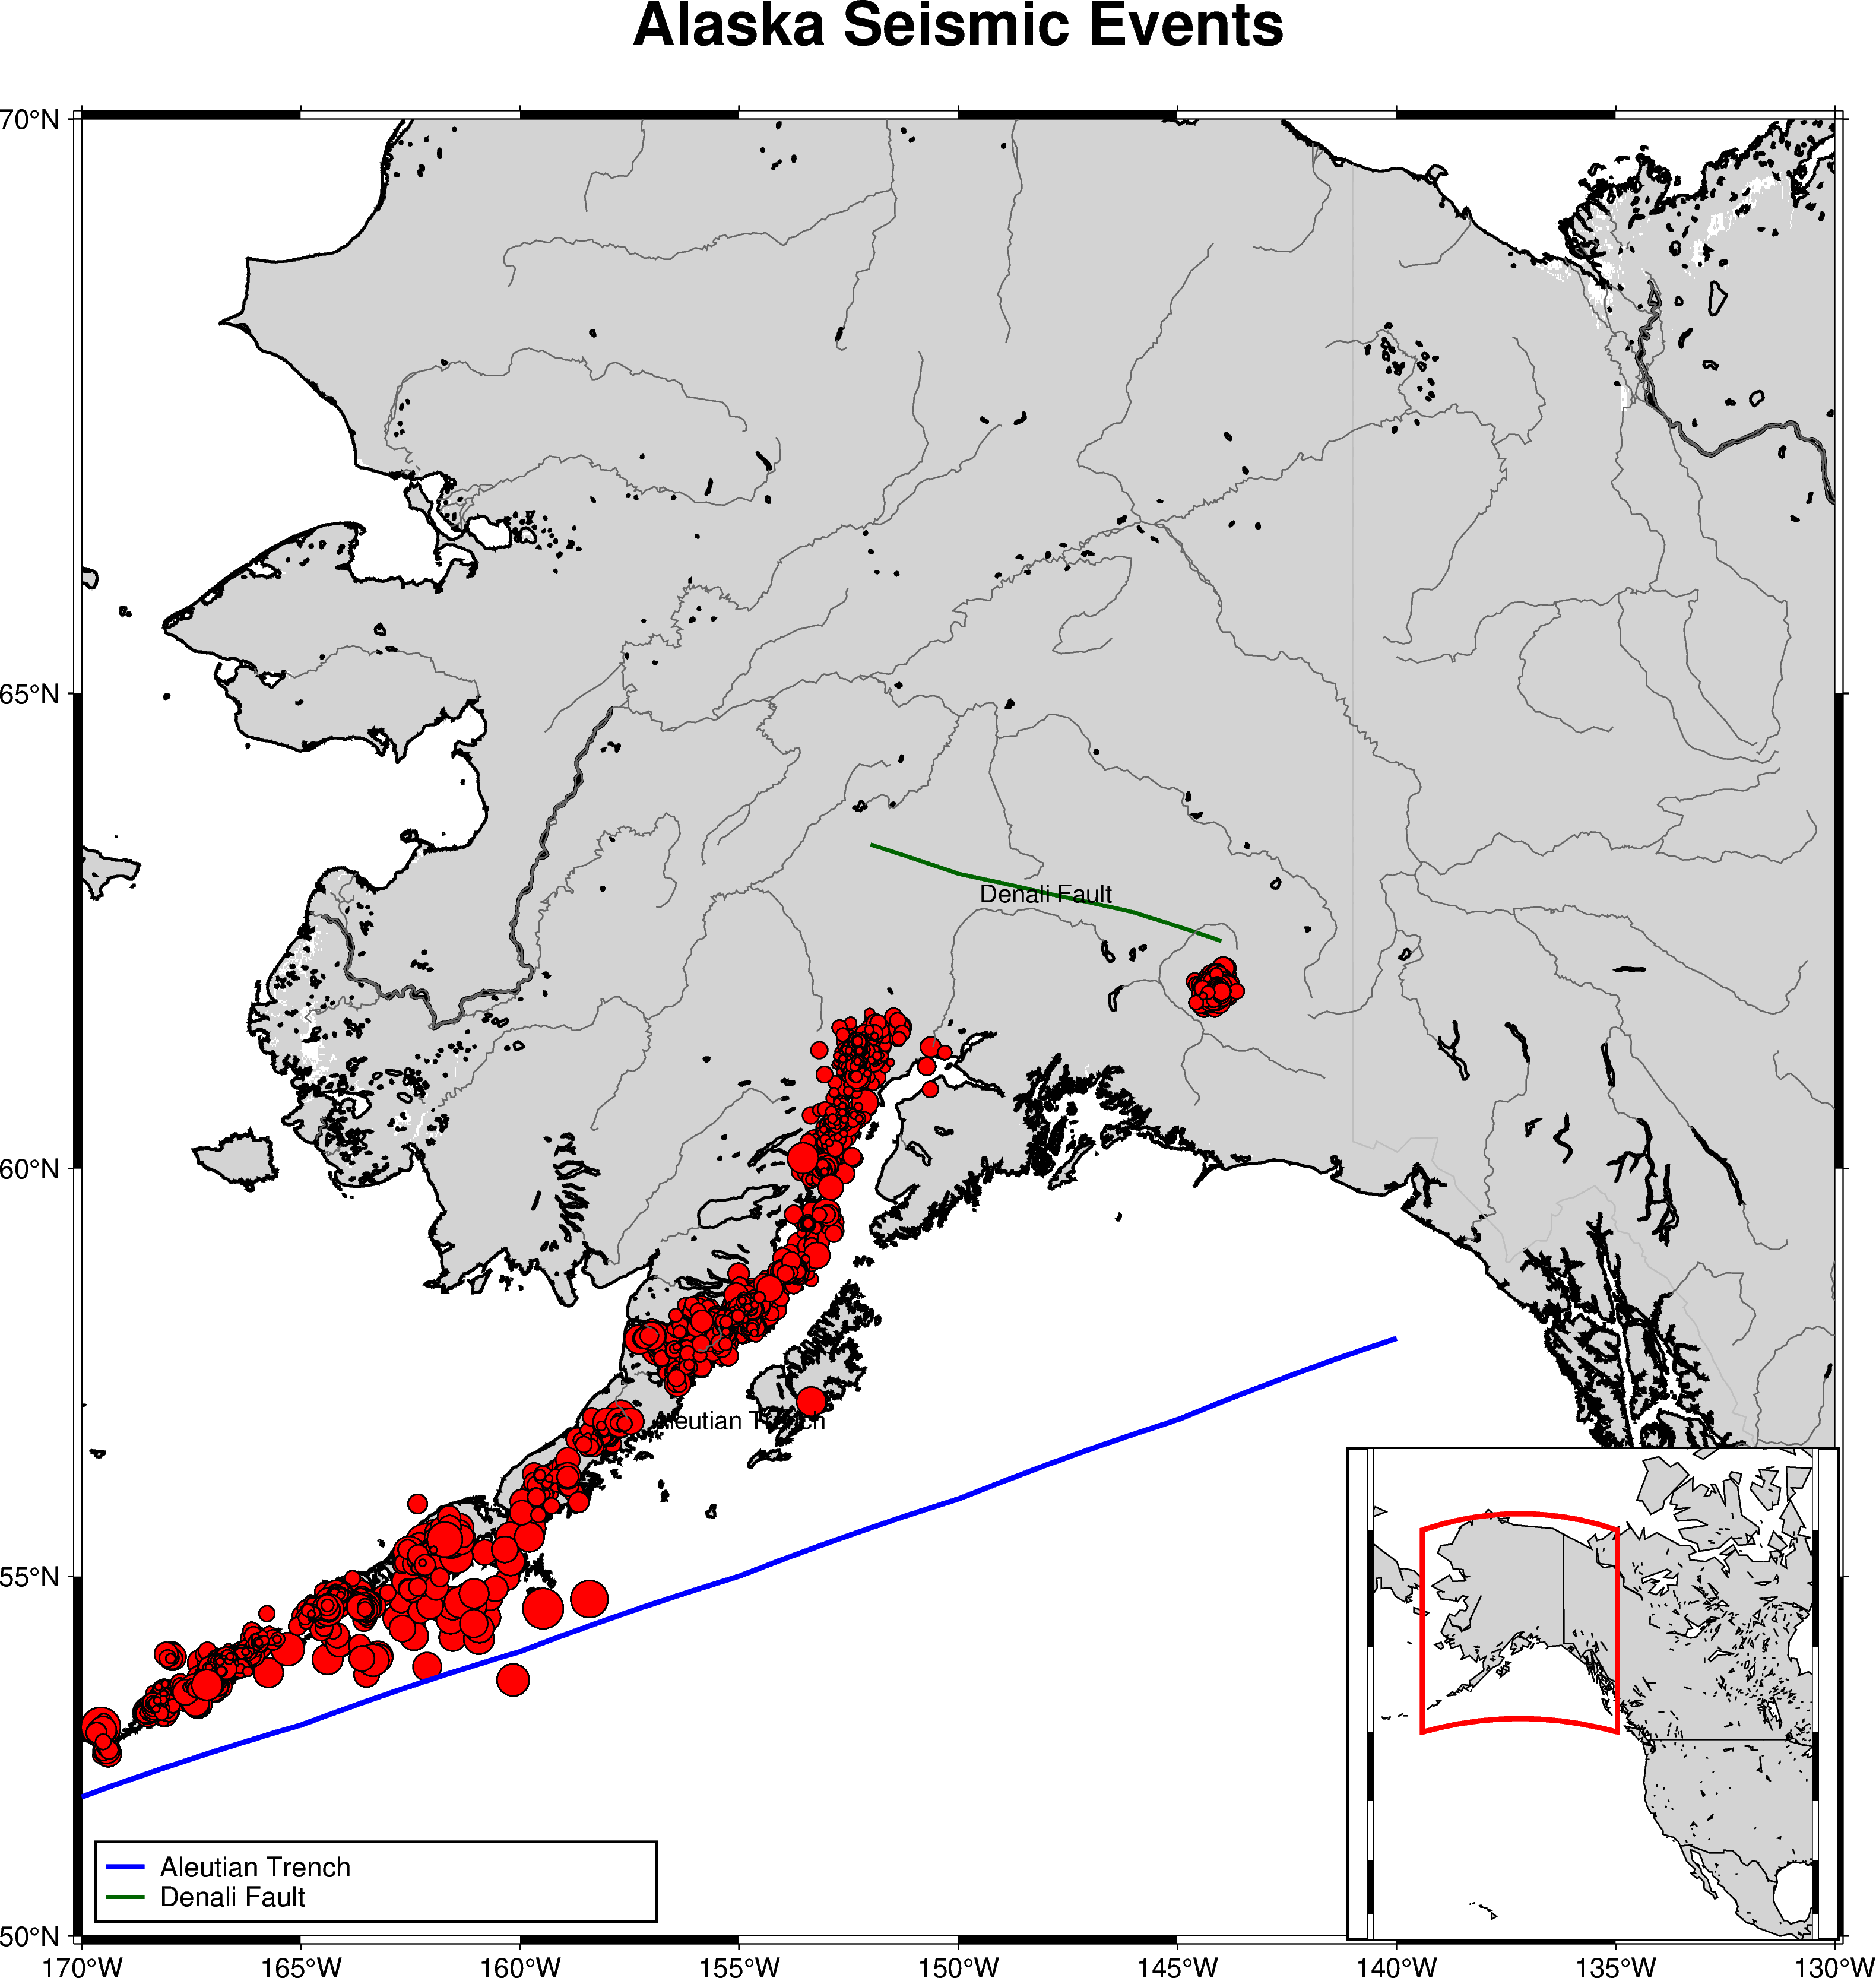

In [7]:
import os
import pygmt
import pandas as pd
import numpy as np
from pathlib import Path

TEMP_DIR = r"D:\pygmt_temp"
os.makedirs(TEMP_DIR, exist_ok=True)
os.environ["TMPDIR"] = TEMP_DIR
os.environ["GMT_TMPDIR"] = TEMP_DIR
os.chdir(TEMP_DIR)
print(f"Temp dir: {TEMP_DIR}")

def normalize_longitude(lon):
    if lon > 180:
        return lon - 360
    elif lon < -180:
        return lon + 360
    return lon

def load_events(file_path):
    if not file_path.exists():
        return pd.DataFrame()
    df = pd.read_csv(file_path)
    rename_dict = {}
    if 'source_longitude_deg' in df.columns:
        rename_dict['source_longitude_deg'] = 'longitude'
    if 'source_latitude_deg' in df.columns:
        rename_dict['source_latitude_deg'] = 'latitude'
    if rename_dict:
        df = df.rename(columns=rename_dict)
    if 'longitude' in df.columns:
        df['longitude'] = df['longitude'].apply(normalize_longitude)
    if 'source_magnitude' in df.columns and 'magnitude' not in df.columns:
        df['magnitude'] = df['source_magnitude']
    elif 'magnitude' not in df.columns:
        df['magnitude'] = 1.0
    return df

base_dir = Path("D:/seisbench_data/vcseis")
csv_files = {
    "LP": base_dir / "ak_lp" / "metadata_ak_lp.csv",
    "VT": base_dir / "ak_vt" / "metadata_ak_rg.csv",
    "NS": base_dir / "ak_ns" / "metadata_aknoise.csv"
}

dfs = []
for name, path in csv_files.items():
    df = load_events(path)
    if not df.empty:
        dfs.append((name, df))
        print(f"{name}: {len(df)} event have been loaded")
    else:
        print(f"{name}, no data")

main_dfs = [df for name, df in dfs if name in ['LP', 'VT']]
if main_dfs:
    main_events = pd.concat(main_dfs, ignore_index=True)
    main_events = main_events.dropna(subset=["longitude", "latitude"])
else:
    np.random.seed(42)
    n_sim = 300
    main_events = pd.DataFrame({
        'longitude': np.random.uniform(-165, -135, n_sim),
        'latitude': np.random.uniform(55, 68, n_sim),
        'magnitude': np.random.uniform(2.0, 6.5, n_sim)
    })

ns_df = None
for name, df in dfs:
    if name == 'NS' and not df.empty:
        ns_df = df.dropna(subset=["longitude", "latitude"]).copy()
        print(f"noise data: {len(ns_df)}")
        break

print(f"Total event: {len(main_events)}")

region_main = [-170, -130, 50, 70]
proj_main = "M25c"
fig = pygmt.Figure()

try:
    grid = pygmt.datasets.load_earth_relief(resolution="01m", region=region_main)
    zmin = grid.data.min().item()
    zmax = grid.data.max().item()
    land_gray = "lightgray"
    cpt_file = "uniform_land_gray.cpt"
    with open(cpt_file, "w") as f:
        f.write(f"{zmin:.0f}\twhite\t0\twhite\n")
        f.write(f"0\t{land_gray}\t{zmax:.0f}\t{land_gray}\n")
        f.write("B white\n")
        f.write("F black\n")
    fig.grdimage(grid=grid, projection=proj_main, cmap=cpt_file)
except:
    fig.basemap(region=region_main, projection=proj_main, frame=True, fill="gray90")

fig.coast(resolution="f", shorelines="1p,black", borders="1/0.5p,gray",
          frame=["a", "+tAlaska Seismic Events"])

if not main_events.empty:
    main_events["size"] = np.clip(np.abs(main_events["magnitude"]) * 0.12 + 0.06, 0.1, 0.8)
    fig.plot(x=main_events.longitude, y=main_events.latitude, size=main_events["size"],
             style="cc", fill="red", pen="0.5p,black", label="LP+VT events")

if ns_df is not None and not ns_df.empty:
    fig.plot(x=ns_df.longitude, y=ns_df.latitude, style="c0.1c",
             fill="gray50", pen="0.2p,gray", label="Noise events")

aleutian_x = [-170, -165, -160, -155, -150, -145, -140]
aleutian_y = [52, 53, 54, 55, 56, 57, 58]
fig.plot(x=aleutian_x, y=aleutian_y, pen="2p,blue,solid", label="Aleutian Trench")
denali_x = [-152, -150, -148, -146, -144]
denali_y = [63.5, 63.2, 63.0, 62.8, 62.5]
fig.plot(x=denali_x, y=denali_y, pen="1.5p,darkgreen,solid", label="Denali Fault")
fig.text(x=-155, y=57, text="Aleutian Trench", font="10p,black", angle=0, justify="CM")
fig.text(x=-148, y=63, text="Denali Fault", font="10p,black", angle=0, justify="CM")

fig.legend(position="JBL+jBL+o0.2c/0.2c+w8c", box="+gwhite+p1p")

try:
    fig.coast(rivers="a/0.5p,gray40")
except:
    pass

with fig.inset(position="jBR+o-0.05c/-0.05c+w7c", box="+gwhite+p1p"):
    fig.coast(
        region=[-180, -90, 15, 75],       
        projection="M?",
        land="lightgray", water="white",
        shorelines="0.5p",
        borders="1/0.5p,black",
        frame="f"
    )
    w, e, s, n = region_main
    fig.plot(x=[w, e, e, w, w], y=[s, s, n, n, s], pen="2p,red")

out_pdf = "D:/Alaska_Seismic_Map_Mercator.pdf"
# fig.savefig(out_pdf)
print(f"✅ map have been saved: {out_pdf}")
fig.show()

Temp dir: D:\pygmt_temp
 LP: 16906 events have been loaded
 VT: 16814 events have been loaded
 NS: 5198 events have been loaded
Events number: 33720


plot [WARNING]: Cannot use auto-legend -l for variable symbol size unless +S<size> is used. Option -l ignored.


✅ Map has been saved: D:/Hawaii_Seismic_Map.pdf


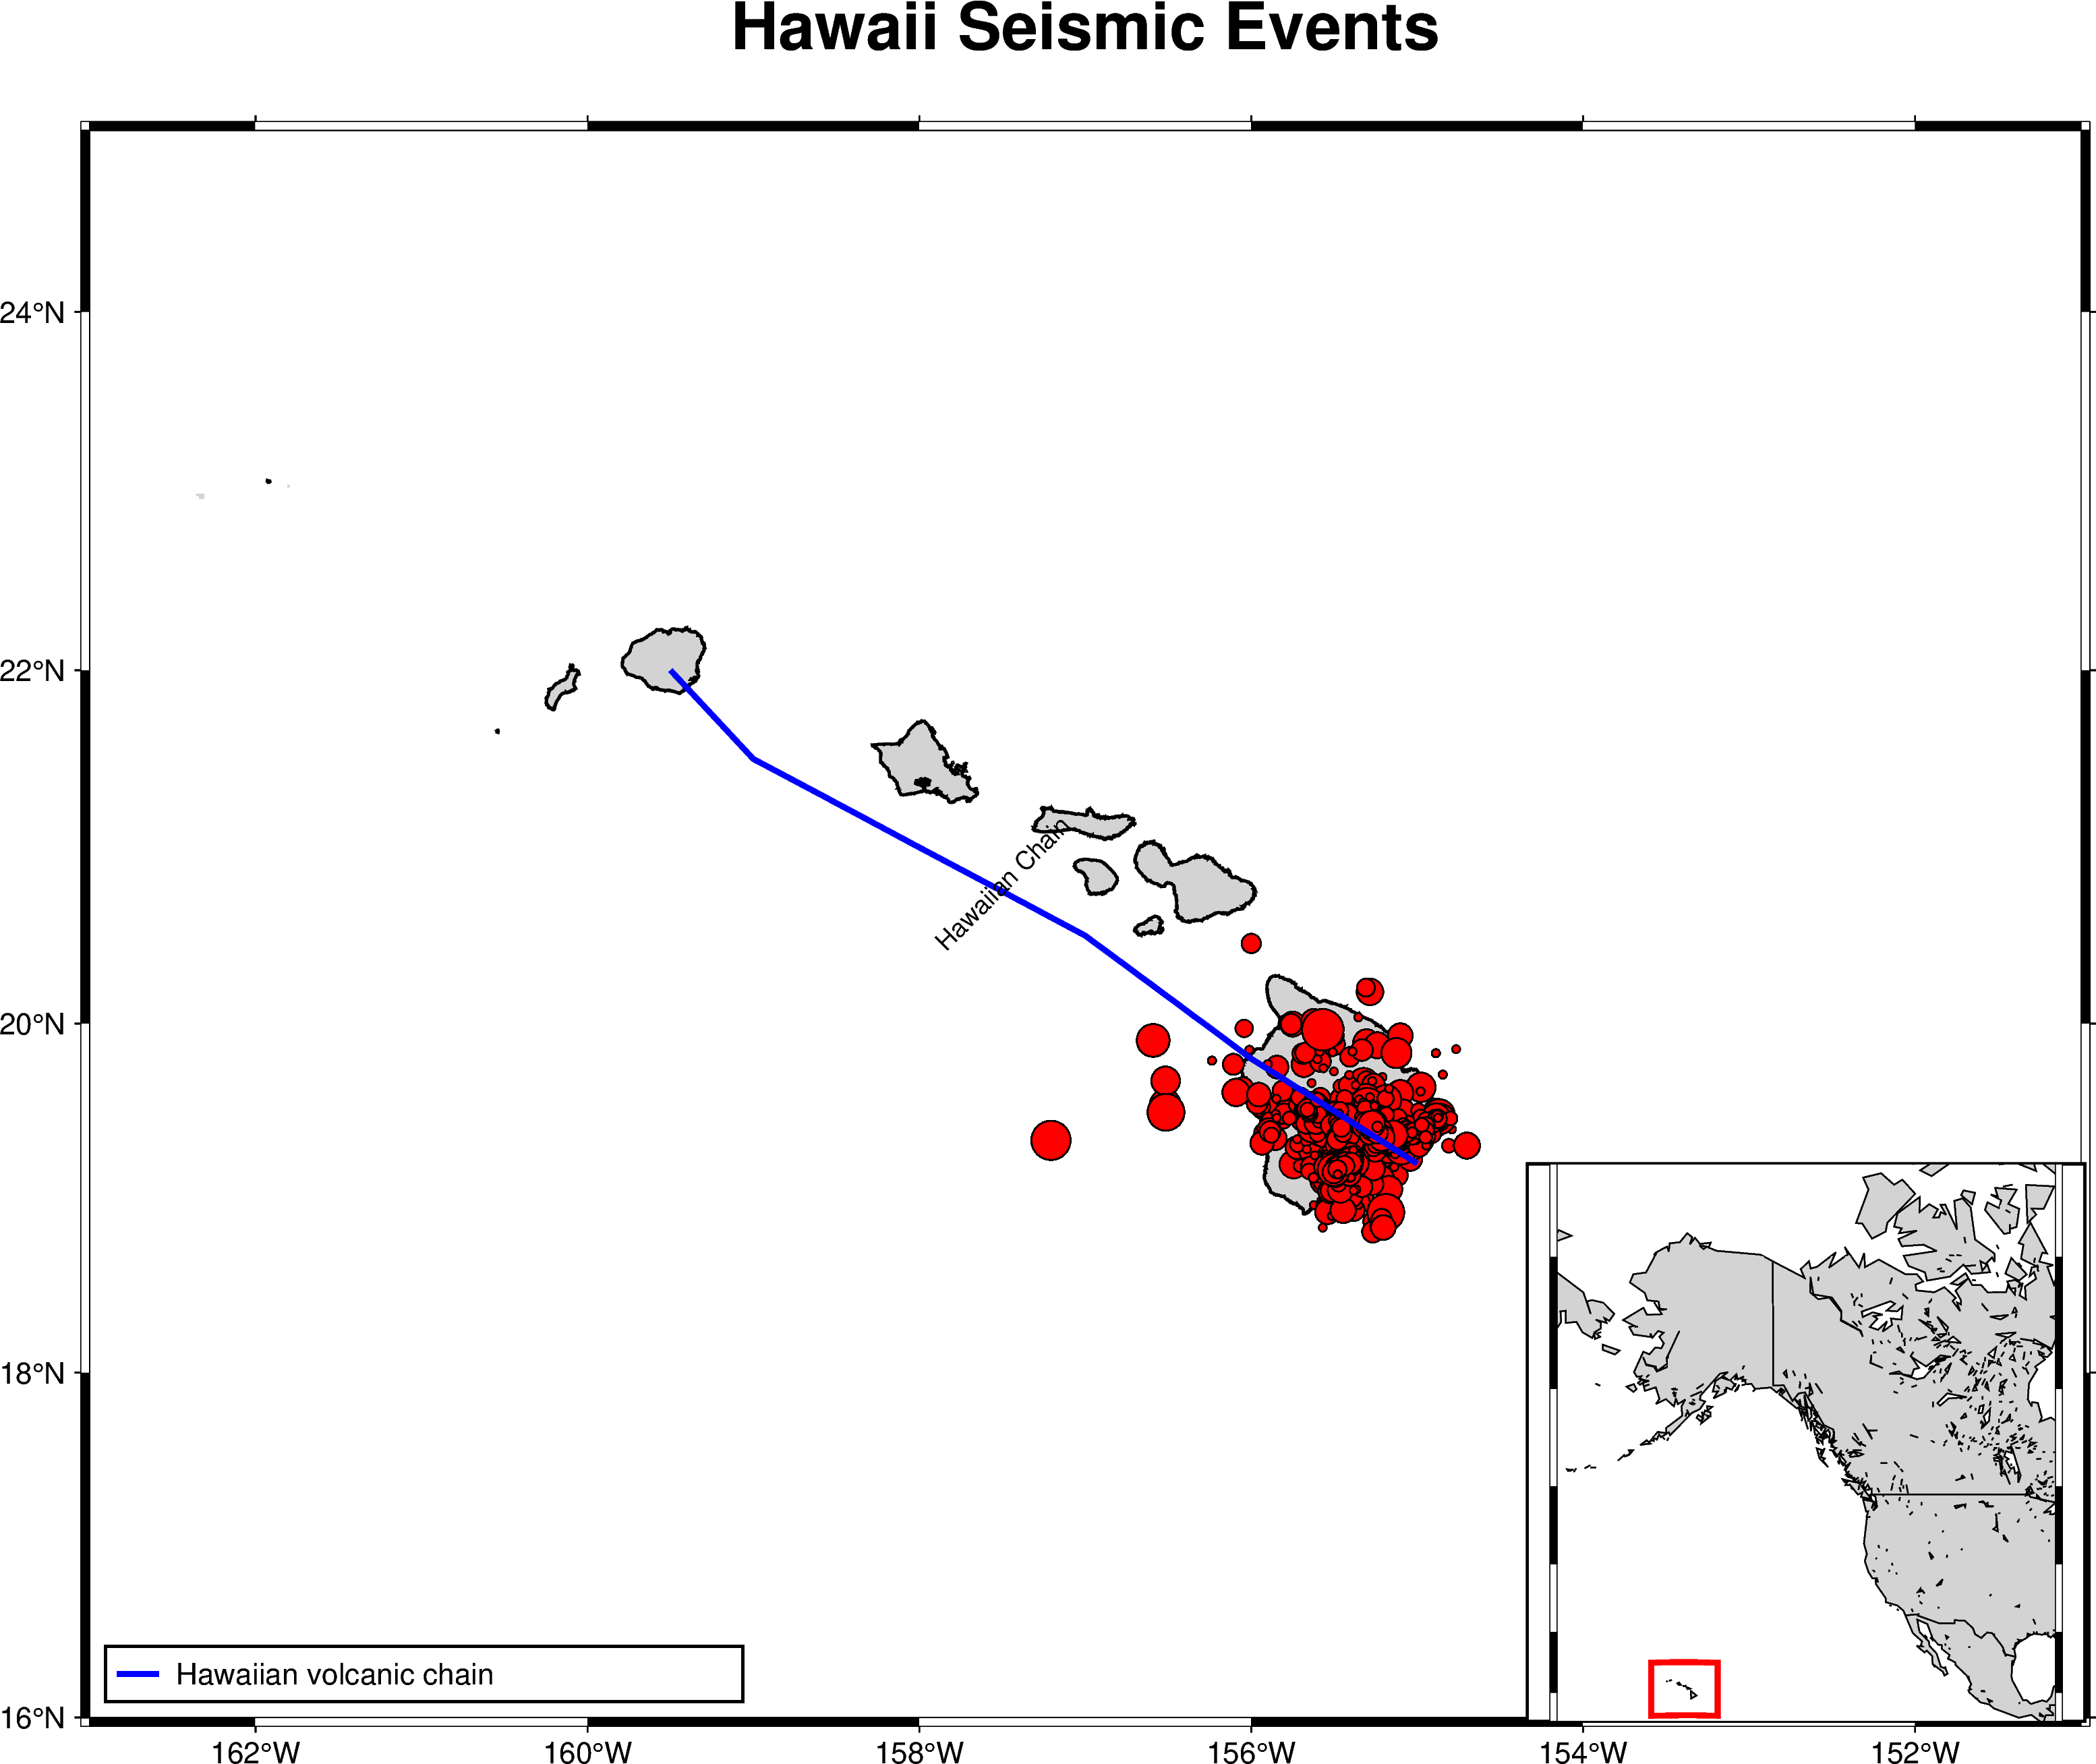

In [15]:
import os
import pygmt
import pandas as pd
import numpy as np
from pathlib import Path

TEMP_DIR = r"D:\pygmt_temp"
os.makedirs(TEMP_DIR, exist_ok=True)
os.environ["TMPDIR"] = TEMP_DIR
os.environ["GMT_TMPDIR"] = TEMP_DIR
os.chdir(TEMP_DIR)
print(f"Temp dir: {TEMP_DIR}")

def normalize_longitude(lon):
    if lon > 180:
        return lon - 360
    elif lon < -180:
        return lon + 360
    return lon

def load_events(file_path):
    if not file_path.exists():
        return pd.DataFrame()
    df = pd.read_csv(file_path)
    rename_dict = {}
    if 'source_longitude_deg' in df.columns:
        rename_dict['source_longitude_deg'] = 'longitude'
    if 'source_latitude_deg' in df.columns:
        rename_dict['source_latitude_deg'] = 'latitude'
    if rename_dict:
        df = df.rename(columns=rename_dict)
    if 'longitude' in df.columns:
        df['longitude'] = df['longitude'].apply(normalize_longitude)
    if 'source_magnitude' in df.columns and 'magnitude' not in df.columns:
        df['magnitude'] = df['source_magnitude']
    elif 'magnitude' not in df.columns:
        df['magnitude'] = 1.0
    return df

base_dir = Path("D:/seisbench_data/vcseis")
csv_files = {
    "LP": base_dir / "hw_lp" / "metadata_hw12t21_lp.csv",
    "VT": base_dir / "hw_vt" / "metadata_hw12t21_rg.csv",
    "NS": base_dir / "hw_ns" / "metadata_hwnoise.csv"
}

dfs = []
for name, path in csv_files.items():
    df = load_events(path)
    if not df.empty:
        dfs.append((name, df))
        print(f" {name}: {len(df)} events have been loaded")
    else:
        print(f" {name}, have been passed")

main_dfs = [df for name, df in dfs if name in ['LP', 'VT']]
if main_dfs:
    main_events = pd.concat(main_dfs, ignore_index=True)
    main_events = main_events.dropna(subset=["longitude", "latitude"])
else:
    np.random.seed(42)
    n_sim = 500
    main_events = pd.DataFrame({
        'longitude': np.random.uniform(-160, -154, n_sim),
        'latitude': np.random.uniform(18, 23, n_sim),
        'magnitude': np.random.uniform(1.0, 5.0, n_sim)
    })

ns_df = None
for name, df in dfs:
    if name == 'NS' and not df.empty:
        ns_df = df.dropna(subset=["longitude", "latitude"]).copy()
        break

print(f"Events number: {len(main_events)}")

region_main = [-163, -151, 16, 25]
proj_main = "M25c"
fig = pygmt.Figure()

try:
    grid = pygmt.datasets.load_earth_relief(resolution="01m", region=region_main)
    zmin = grid.data.min().item()
    zmax = grid.data.max().item()
    land_gray = "lightgray"
    cpt_file = "uniform_land_gray.cpt"
    with open(cpt_file, "w") as f:
        f.write(f"{zmin:.0f}\twhite\t0\twhite\n")
        f.write(f"0\t{land_gray}\t{zmax:.0f}\t{land_gray}\n")
        f.write("B white\n")
        f.write("F black\n")
    fig.grdimage(grid=grid, projection=proj_main, cmap=cpt_file)
except Exception as e:
    fig.basemap(region=region_main, projection=proj_main, frame=True, fill="gray90")

fig.coast(
    resolution="f",
    shorelines="1p,black",
    borders="1/0.5p,gray",
    frame=["a", "+tHawaii Seismic Events"]
)

if not main_events.empty:
    main_events["size"] = np.clip(np.abs(main_events["magnitude"]) * 0.12 + 0.06, 0.1, 0.8)
    fig.plot(
        x=main_events.longitude,
        y=main_events.latitude,
        size=main_events["size"],
        style="cc",
        fill="red",
        pen="0.5p,black",
        label="LP+VT events"
    )

if ns_df is not None and not ns_df.empty:
    fig.plot(
        x=ns_df.longitude,
        y=ns_df.latitude,
        style="c0.1c",
        fill="gray50",
        pen="0.2p,gray",
        label="Noise events"
    )

hawaii_chain_x = [-159.5, -159.0, -158.0, -157.0, -156.0, -155.0]
hawaii_chain_y = [22.0, 21.5, 21.0, 20.5, 19.8, 19.2]
fig.plot(x=hawaii_chain_x, y=hawaii_chain_y, pen="2p,blue,solid", label="Hawaiian volcanic chain")
fig.text(x=-157.5, y=20.8, text="Hawaiian Chain", font="9p,black", angle=45, justify="CM")

fig.legend(position="JBL+jBL+o0.2c/0.2c+w8c", box="+gwhite+p1p")

with fig.inset(position="jBR+o-0.05c/-0.05c+w7c", box="+gwhite+p1p"):
    fig.coast(
        region=[-180, -90, 15, 75],
        projection="M?",
        land="lightgray", water="white",
        shorelines="0.5p",
        borders="1/0.5p,black",
        frame="f"
    )
    w, e, s, n = region_main
    fig.plot(x=[w, e, e, w, w], y=[s, s, n, n, s], pen="2p,red")

out_pdf = "D:/Hawaii_Seismic_Map.pdf"
# fig.savefig(out_pdf)
print(f"✅ Map has been saved: {out_pdf}")
fig.show()

Temp dir: D:\pygmt_temp
 LP: 810
 VT: 810
Event number: 1620


plot [WARNING]: Cannot use auto-legend -l for variable symbol size unless +S<size> is used. Option -l ignored.


✅ Map has been saved: D:/Cascade_Seismic_Map.pdf


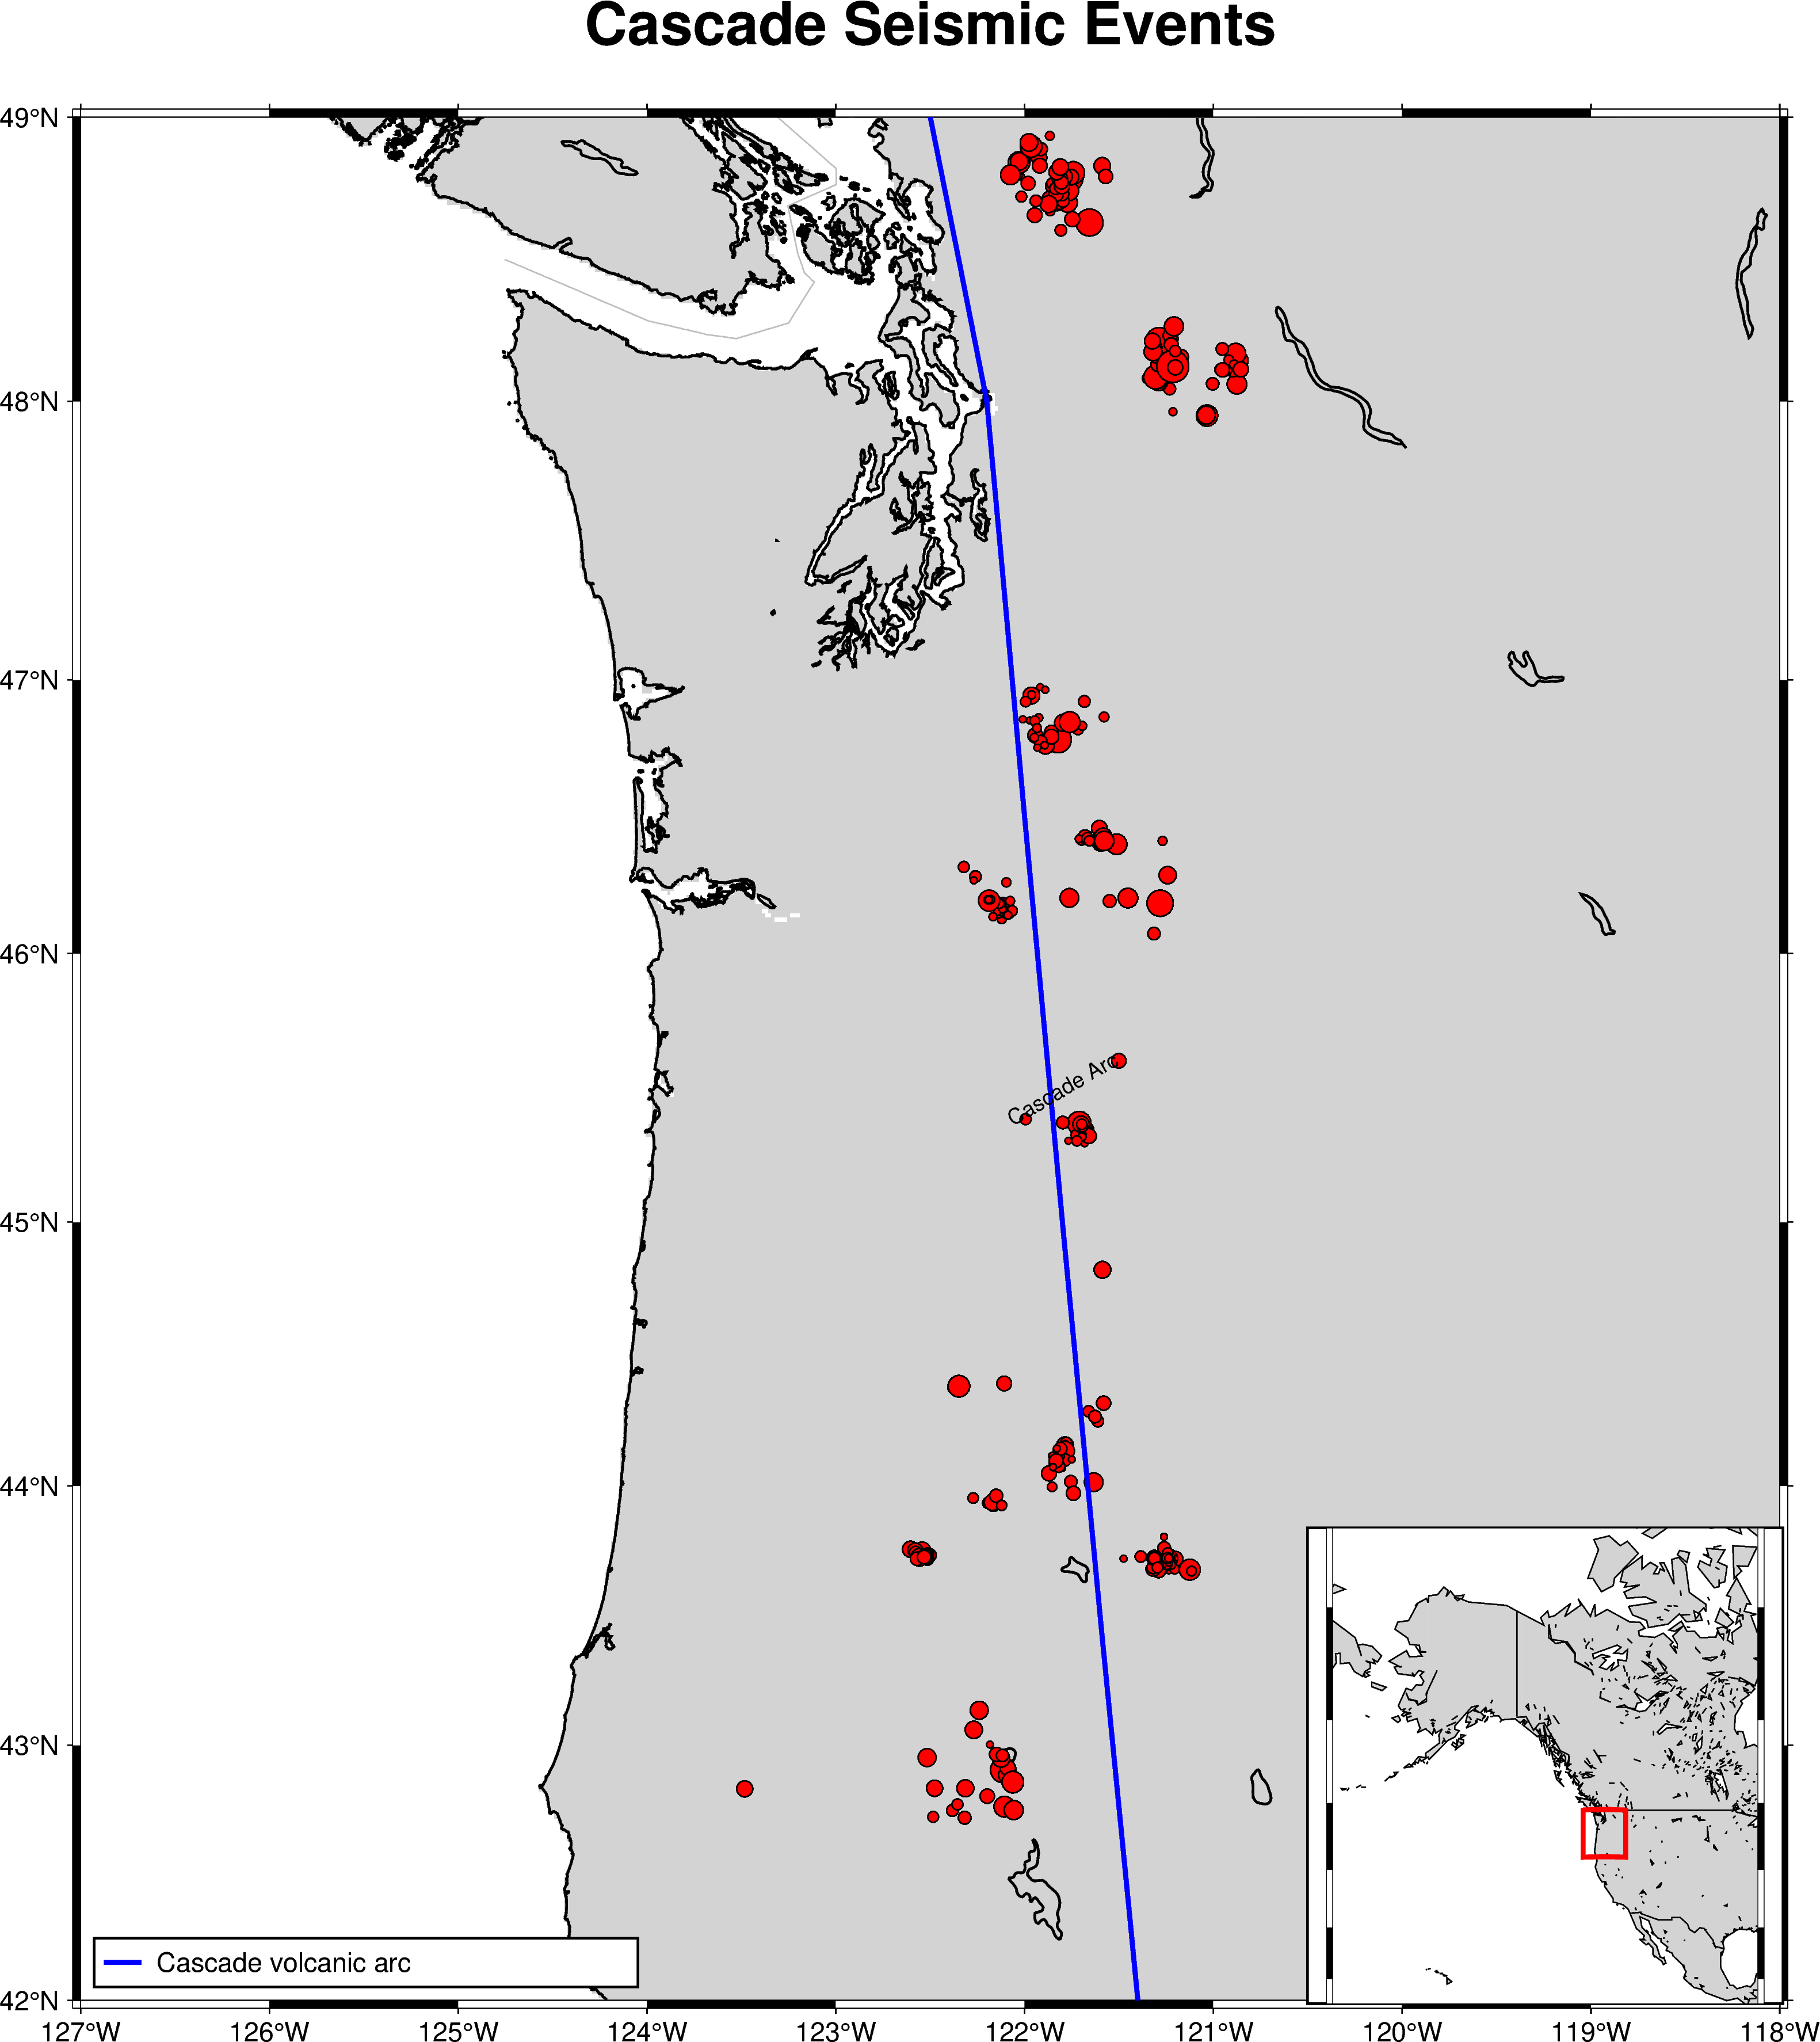

In [9]:
import os
import pygmt
import pandas as pd
import numpy as np
from pathlib import Path

TEMP_DIR = r"D:\pygmt_temp"
os.makedirs(TEMP_DIR, exist_ok=True)
os.environ["TMPDIR"] = TEMP_DIR
os.environ["GMT_TMPDIR"] = TEMP_DIR
os.chdir(TEMP_DIR)
print(f"Temp dir: {TEMP_DIR}")

def normalize_longitude(lon):
    if lon > 180:
        return lon - 360
    elif lon < -180:
        return lon + 360
    return lon

def load_events(file_path):
    if not file_path.exists():
        return pd.DataFrame()
    df = pd.read_csv(file_path)
    rename_dict = {}
    if 'source_longitude_deg' in df.columns:
        rename_dict['source_longitude_deg'] = 'longitude'
    if 'source_latitude_deg' in df.columns:
        rename_dict['source_latitude_deg'] = 'latitude'
    if rename_dict:
        df = df.rename(columns=rename_dict)
    if 'longitude' in df.columns:
        df['longitude'] = df['longitude'].apply(normalize_longitude)
    if 'source_magnitude' in df.columns and 'magnitude' not in df.columns:
        df['magnitude'] = df['source_magnitude']
    elif 'magnitude' not in df.columns:
        df['magnitude'] = 1.0
    return df

base_dir = Path("D:/seisbench_data/vcseis")
csv_files = {
    "LP": base_dir / "cas_lp" / "metadata_cascade_lp.csv",
    "VT": base_dir / "cas_vt" / "metadata_cascade_vt.csv",
}

dfs = []
for name, path in csv_files.items():
    df = load_events(path)
    if not df.empty:
        dfs.append(df)
        print(f" {name}: {len(df)}")
    else:
        print(f"{name} passed")

if dfs:
    main_events = pd.concat(dfs, ignore_index=True)
    main_events = main_events.dropna(subset=["longitude", "latitude"])
else:
    np.random.seed(42)
    n_sim = 300
    main_events = pd.DataFrame({
        'longitude': np.random.uniform(-124, -120, n_sim),
        'latitude': np.random.uniform(42, 49, n_sim),
        'magnitude': np.random.uniform(1.0, 4.5, n_sim)
    })

print(f"Event number: {len(main_events)}")

region_main = [-127, -118, 42, 49]  
proj_main = "M25c"                   
fig = pygmt.Figure()

try:
    grid = pygmt.datasets.load_earth_relief(resolution="01m", region=region_main)
    zmin = grid.data.min().item()
    zmax = grid.data.max().item()
    land_gray = "lightgray"
    cpt_file = "uniform_land_gray.cpt"
    with open(cpt_file, "w") as f:
        f.write(f"{zmin:.0f}\twhite\t0\twhite\n")
        f.write(f"0\t{land_gray}\t{zmax:.0f}\t{land_gray}\n")
        f.write("B white\n")
        f.write("F black\n")
    fig.grdimage(grid=grid, projection=proj_main, cmap=cpt_file)
except Exception as e:
    fig.basemap(region=region_main, projection=proj_main, frame=True, fill="gray90")

fig.coast(
    resolution="f",
    shorelines="1p,black",
    borders="1/0.5p,gray",
    frame=["a", "+tCascade Seismic Events"]
)

if not main_events.empty:
    main_events["size"] = np.clip(np.abs(main_events["magnitude"]) * 0.12 + 0.06, 0.1, 0.8)
    fig.plot(
        x=main_events.longitude,
        y=main_events.latitude,
        size=main_events["size"],
        style="cc",
        fill="red",
        pen="0.5p,black",
        label="LP+VT events"
    )

cascade_x = [-122.5, -122.2, -122.0, -121.8, -121.6, -121.4]
cascade_y = [49.0, 48.0, 46.5, 45.0, 43.5, 42.0]
fig.plot(x=cascade_x, y=cascade_y, pen="2p,blue,solid", label="Cascade volcanic arc")

fig.text(x=-121.8, y=45.5, text="Cascade Arc", font="9p,black", angle=30, justify="CM")

fig.legend(position="JBL+jBL+o0.2c/0.2c+w8c", box="+gwhite+p1p")

with fig.inset(position="jBR+o-0.05c/-0.05c+w7c", box="+gwhite+p1p"):
    fig.coast(
        region=[-180, -90, 15, 75],
        projection="M?",
        land="lightgray", water="white",
        shorelines="0.5p",
        borders="1/0.5p,black",
        frame="f"
    )
    w, e, s, n = region_main
    fig.plot(x=[w, e, e, w, w], y=[s, s, n, n, s], pen="2p,red")

out_pdf = "D:/Cascade_Seismic_Map.pdf"
# fig.savefig(out_pdf)
print(f"✅ Map has been saved: {out_pdf}")
fig.show()

### Magnitude-frequency

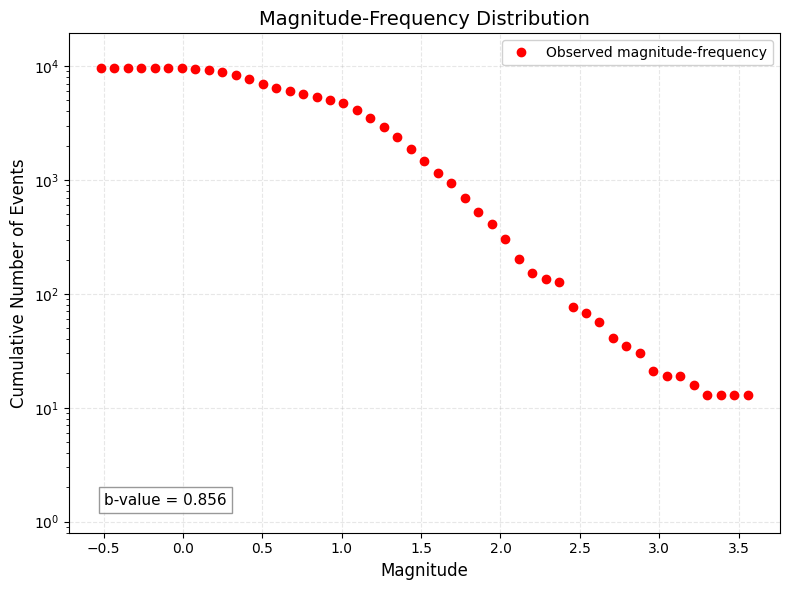

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats


def load_events(file_path):
    if not file_path.exists():
        return pd.DataFrame()
    df = pd.read_csv(file_path)
    df = df.rename(columns={
        'source_longitude_deg': 'longitude',
        'source_latitude_deg': 'latitude',
        'source_magnitude': 'mag'
    })
    return df

base_dir = Path("D:/seisbench_data/vcseis")
csv_files = {
    "LP": base_dir / "nc_lp" / "metadata_ncedc_lp.csv",
    "VT": base_dir / "nc_vt" / "metadata_ncedc_vt.csv",
}


dfs = []
for name, f in csv_files.items():
    df = load_events(f)
    if not df.empty:
        dfs.append(df)

all_events = pd.concat(dfs, ignore_index=True)
all_events = all_events.dropna(subset=["mag"])

mag_series = all_events["mag"].dropna()
mag_series = mag_series[(mag_series >= -2) & (mag_series <= 8)]
m_min, m_max = mag_series.min(), mag_series.max()

bins = np.linspace(m_min, m_max + 0.01, 50)
counts, edges = np.histogram(mag_series, bins=bins)
cents = (edges[:-1] + edges[1:]) / 2
cum_counts = np.array([np.sum(counts[i:]) for i in range(len(counts))])
valid = cum_counts > 0
cents, cum_counts = cents[valid], cum_counts[valid]

b_value = None
if len(cents) > 2:
    logN = np.log10(cum_counts)
    slope, intercept, r_val, p_val, se = stats.linregress(cents, logN)
    b_value = abs(slope)

fig, ax = plt.subplots(figsize=(8, 6))

ax.semilogy(cents, cum_counts, 'ro', markersize=6, label='Observed magnitude-frequency')

ax.set_xlabel('Magnitude', fontsize=12)
ax.set_ylabel('Cumulative Number of Events', fontsize=12)
ax.set_title('Magnitude-Frequency Distribution', fontsize=14)

ax.grid(True, alpha=0.3, linestyle='--')

ax.legend(loc='upper right', framealpha=0.9, fontsize=10)

if b_value is not None:
    text_str = f'b-value = {b_value:.3f}'
    ax.text(0.05, 0.05, text_str, transform=ax.transAxes,
            fontsize=11, verticalalignment='bottom',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

ax.set_ylim(0.8, max(cum_counts)*2)

plt.tight_layout()
# plt.savefig("D:/nc-magnitude_frequency_no_fit.pdf", dpi=300)
plt.show()

### Line chart

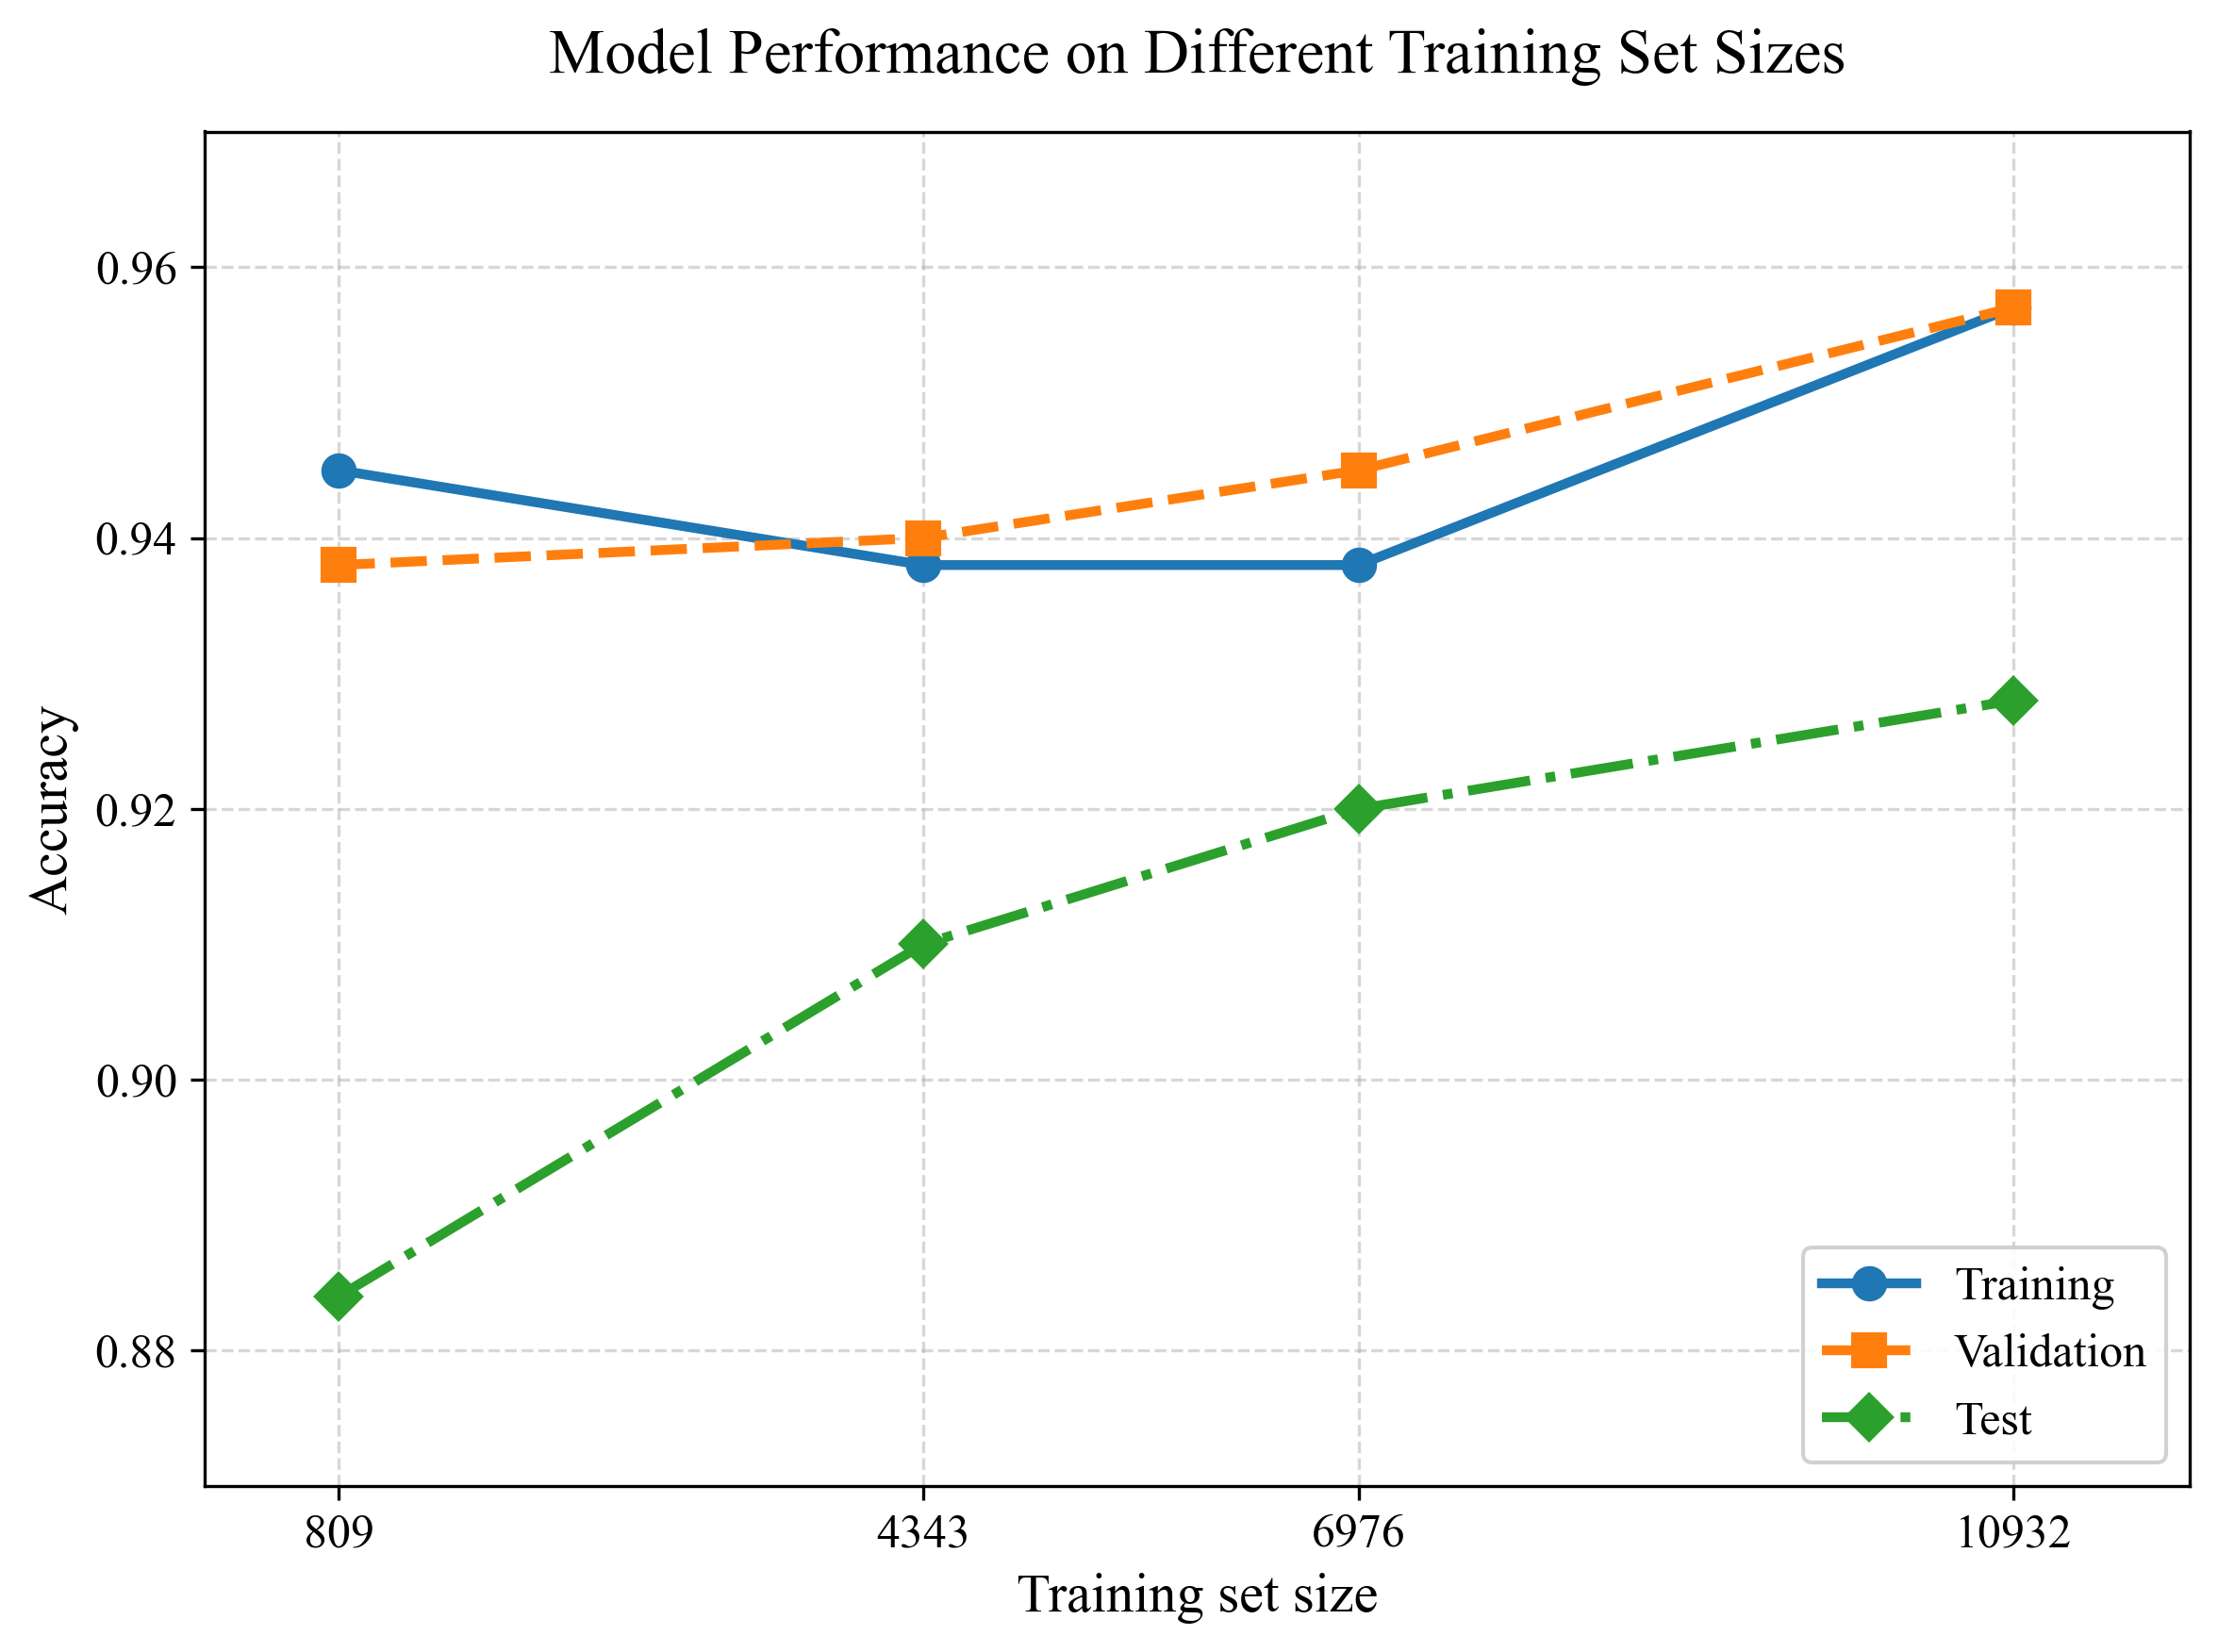

In [9]:
import matplotlib.pyplot as plt
import numpy as np

train_sizes = [809, 4343, 6976, 10932]
train_acc = [0.945, 0.938, 0.938, 0.957]
val_acc   = [0.938, 0.940, 0.945, 0.957]
test_acc  = [0.884, 0.910, 0.920, 0.928]

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(train_sizes, train_acc, 'o-', color='#1f77b4', linewidth=2.5, markersize=8, label='Training')
ax.plot(train_sizes, val_acc,   's--', color='#ff7f0e', linewidth=2.5, markersize=8, label='Validation')
ax.plot(train_sizes, test_acc,  'D-.', color='#2ca02c', linewidth=2.5, markersize=8, label='Test')

ax.set_xticks(train_sizes)
ax.set_xticklabels([str(x) for x in train_sizes], rotation=0, ha='center')

ax.set_xlim(0, 12000)
ax.set_ylim(0.87, 0.97)
ax.set_ylabel('Accuracy', fontsize=14)
ax.set_xlabel('Training set size', fontsize=14)
ax.set_title('Model Performance on Different Training Set Sizes', fontsize=16, pad=15)

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.savefig('accuracy_xticks_values.pdf', dpi=600)
plt.show()

### Radar chart

In [12]:
from math import pi

def plot_radar_with_inverted_sample(models_metrics_dict, metric_names=None, save_path='radar_inverted.png'):
    """
    inv count = 1 - (sample_count / max_count)
    
    params: 
        models_metrics_dict: dict,  {model name: [acc, macro_p, macro_r, weighted_f1, sample_count]}
        metric_names: list, ['Accuracy', 'Macro P', 'Macro R', 'Weighted F1', 'Inv. Sample Count']
        save_path
    """
    if metric_names is None:
        metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'Inv. Sample Count']
    
    sample_counts = [metrics[4] for metrics in models_metrics_dict.values()]
    max_count = max(sample_counts)
    
    normalized_dict = {}
    for name, metrics in models_metrics_dict.items():
        inv_sample = 1 - (metrics[4] / max_count)
        norm_metrics = metrics[:4] + [inv_sample]
        normalized_dict[name] = norm_metrics
    
    N = len(metric_names)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_names, size=12)

    ax.set_rlabel_position(0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], size=10)
    ax.set_ylim(0, 1)

    for i, (model_name, metrics) in enumerate(normalized_dict.items()):
        values = metrics + metrics[:1] 
        color = colors[i % len(colors)]
        ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=color)
        ax.fill(angles, values, alpha=0.2, color=color)

    handles, labels = ax.get_legend_handles_labels()
    enhanced_labels = [f"{name} (n={models_metrics_dict[name][4]})" for name in labels]
    ax.legend(handles, enhanced_labels, loc='upper right', bbox_to_anchor=(1.3, 1.1))

    plt.title('Model Performance (Inverted Normalized Sample Count)', size=14, pad=20)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

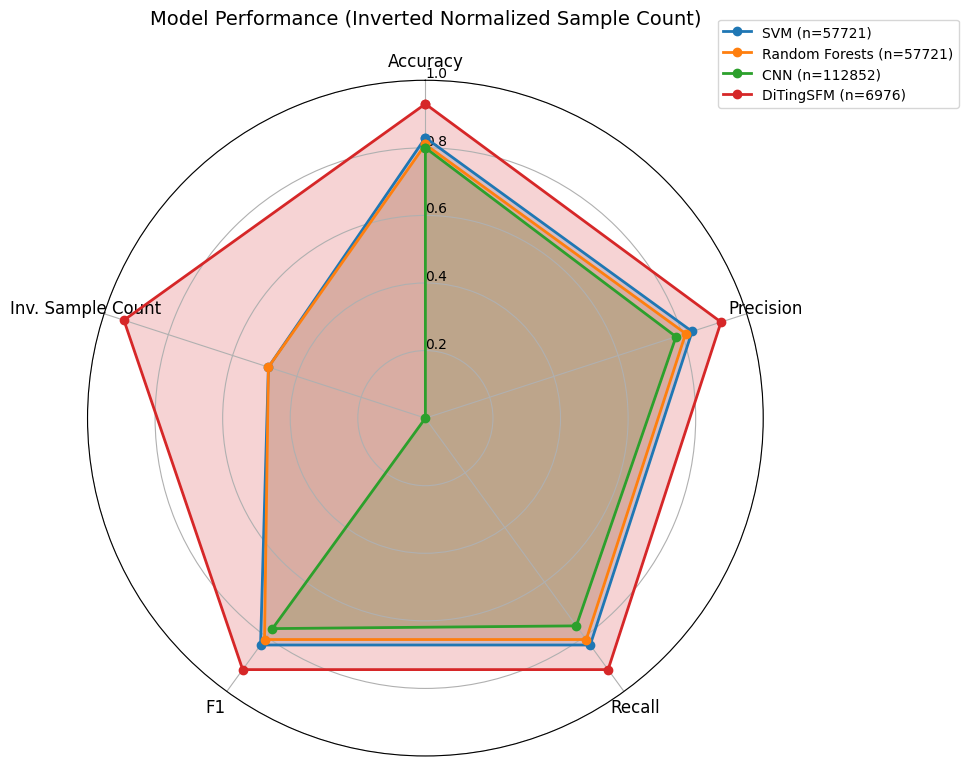

In [14]:

svm_metrics = [0.83, 0.83, 0.83, 0.83, 57721]
rf_metrics = [0.81, 0.81, 0.81, 0.81, 57721]
cnn_metrics = [0.80, 0.78, 0.76, 0.77, 112852]
llm_metrics = [0.93, 0.92, 0.92, 0.92, 6976]

models_metrics_dict = {
    'SVM': svm_metrics,
    'Random Forests': rf_metrics,
    'CNN': cnn_metrics,
    'DiTingSFM': llm_metrics
}


plot_radar_with_inverted_sample(models_metrics_dict, save_path='D:/seisbench_data/radar.png')